# Tutorial - 3

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import time
import copy

# Configure tqdm for pandas operations
tqdm.pandas()

print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")


✓ PyTorch version: 2.6.0+cu124
✓ Device: GPU


In [7]:
# Load data efficiently - only necessary columns
flat_filepath = r'data/FlatFiles/NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx'

# Helper function to convert period column name to float
def period_to_float(col_name):
    """Convert column name like T0pt010S to 0.010"""
    period_str = col_name[1:-1].replace('pt', '.')
    return float(period_str)

# Get all column names first
print("Reading column names...")
df_temp = pd.read_excel(flat_filepath, engine='calamine', nrows=0)
all_cols = df_temp.columns.tolist()

# Find period columns <= 4.0 seconds only
period_cols = [col for col in all_cols if col.startswith('T') and col.endswith('S')]
selected_period_cols = [col for col in period_cols if period_to_float(col) <= 4.0]
selected_period_cols_sorted = sorted(selected_period_cols, key=period_to_float)

# Define columns to load
selected_columns = [
    'Earthquake_Magnitude',
    'Rjb_km',
    'Vs30_Selected_for_Analysis_m_s',
    'Fault_Type',
    'PGA_g',
    'PGV_cm_sec'
] + selected_period_cols_sorted

# Define dtypes for faster loading (avoid type inference)
dtype_dict = {
    'Earthquake_Magnitude': 'float32',
    'Rjb_km': 'float32',
    'Vs30_Selected_for_Analysis_m_s': 'float32',
    'Fault_Type': 'int8',
    'PGA_g': 'float32',
    'PGV_cm_sec': 'float32'
}
# Add period columns as float32
for col in selected_period_cols_sorted:
    dtype_dict[col] = 'float32'

print(f"Loading {len(selected_columns)} columns (6 base features + {len(selected_period_cols_sorted)} periods)...")
print(f"Period range: {period_to_float(selected_period_cols_sorted[0]):.3f}s to {period_to_float(selected_period_cols_sorted[-1]):.3f}s")
print("Please wait...")

# Load with dtype specifications for faster processing
df = pd.read_excel(flat_filepath, engine='calamine', usecols=selected_columns, dtype=dtype_dict)

print(f"✓ Loaded data shape: {df.shape}")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Reading column names...
Loading 96 columns (6 base features + 90 periods)...
Period range: 0.010s to 4.000s
Please wait...
✓ Loaded data shape: (71340, 96)
  Memory usage: 25.92 MB


In [8]:
# Data Cleaning: Remove outliers and invalid values
print("="*80)
print("DATA CLEANING")
print("="*80)
print(f"\nOriginal shape: {df.shape}")

# Filter 1: Magnitude >= 4
df = df[df['Earthquake_Magnitude'] >= 4]
print(f"After M >= 4 filter: {df.shape}")

# Filter 2: Distance 0-500 km
df = df[(df['Rjb_km'] >= 0) & (df['Rjb_km'] <= 500)]
print(f"After distance filter: {df.shape}")

# Filter 3: Remove rows with Vs30 <= 0
df = df[df['Vs30_Selected_for_Analysis_m_s'] > 0]
print(f"After Vs30 > 0 filter: {df.shape}")

# Filter 4: PGA realistic range (0-5g)
df = df[(df['PGA_g'] > 0) & (df['PGA_g'] < 5)]
print(f"After PGA filter: {df.shape}")

# Filter 5: PGV realistic range (0-500 cm/s)
df = df[(df['PGV_cm_sec'] > 0) & (df['PGV_cm_sec'] < 500)]
print(f"After PGV filter: {df.shape}")

# Filter 6: Remove rows with invalid spectral values (with progress bar)
print(f"\nFiltering {len(selected_period_cols_sorted)} spectral acceleration columns...")
for col in tqdm(selected_period_cols_sorted, desc="Filtering Sa columns"):
    df = df[(df[col] > 0) & (df[col] < 5)]

print(f"After spectral value filters: {df.shape}")

# Reset index
df = df.reset_index(drop=True)
print(f"\n✓ Final cleaned data: {len(df):,} earthquakes")
print("="*80)


DATA CLEANING

Original shape: (71340, 96)
After M >= 4 filter: (68473, 96)
After distance filter: (55395, 96)
After Vs30 > 0 filter: (55152, 96)
After PGA filter: (55062, 96)
After PGV filter: (55062, 96)

Filtering 90 spectral acceleration columns...


Filtering Sa columns: 100%|██████████| 90/90 [00:00<00:00, 524.40it/s]

After spectral value filters: (55057, 96)

✓ Final cleaned data: 55,057 earthquakes


# Multi-Output ANN for Ground Motion Prediction

In [9]:
# Data Processing: Create log-transformed features and targets
print("="*80)
print("DATA PREPROCESSING")
print("="*80)

print(f"\nStarting with {df.shape[0]:,} samples after cleaning...")

# Additional safety filters for log transformation
print("\nApplying safety checks for log transformations...")
initial_count = len(df)

# Ensure Rjb_km >= 0.001 (avoid log(0))
df = df[df['Rjb_km'] >= 0.001]
print(f"  After Rjb >= 0.001 check: {len(df):,} samples (-{initial_count - len(df)})")

# Ensure Vs30 in reasonable range [100, 2000] m/s
df = df[(df['Vs30_Selected_for_Analysis_m_s'] >= 100) & 
        (df['Vs30_Selected_for_Analysis_m_s'] <= 3000)]
print(f"  After Vs30 range check: {len(df):,} samples")

df = df.reset_index(drop=True)

# Create log10-transformed features (will be used as inputs)
print("\nCreating log-transformed input features...")
df['log10_Rjb_km'] = np.log10(df['Rjb_km'])
df['log10_Vs30'] = np.log10(df['Vs30_Selected_for_Analysis_m_s'])
print("  ✓ log10_Rjb_km")
print("  ✓ log10_Vs30")

# Create log10-transformed targets (will be used as outputs)
print("\nCreating log-transformed target variables...")
df['log10_PGA_g'] = np.log10(df['PGA_g'])
df['log10_PGV_cm_sec'] = np.log10(df['PGV_cm_sec'])
print("  ✓ log10_PGA_g")
print("  ✓ log10_PGV_cm_sec")

# Add log10 for all spectral acceleration periods (with progress bar)
print(f"\nCreating log10 for {len(selected_period_cols_sorted)} spectral periods...")
for col in tqdm(selected_period_cols_sorted, desc="Log-transforming Sa"):
    df[f'log10_{col}'] = np.log10(df[col])

# Verify no inf/nan values after log transformation
print("\nVerifying data integrity...")
log_feature_cols = ['log10_Rjb_km', 'log10_Vs30']
log_target_cols = ['log10_PGA_g', 'log10_PGV_cm_sec'] + [f'log10_{col}' for col in selected_period_cols_sorted]

# Check for inf/nan in log-transformed columns
inf_nan_count = 0
print("Checking for inf/nan values in log-transformed columns...")
for col in tqdm(log_feature_cols + log_target_cols, desc="Validating columns"):
    invalid_mask = ~np.isfinite(df[col])
    if invalid_mask.any():
        inf_nan_count += invalid_mask.sum()
        df = df[~invalid_mask]

if inf_nan_count > 0:
    print(f"  ⚠ Removed {inf_nan_count} rows with inf/nan values")
    df = df.reset_index(drop=True)
else:
    print(f"  ✓ All values are finite and valid")

# Summary
print("\n" + "="*80)
print("PREPROCESSING COMPLETE")
print("="*80)
print(f"Final dataset: {len(df):,} samples × {len(df.columns)} columns")
print(f"\nInput features (5):")
print("  1. Earthquake_Magnitude")
print("  2. Rjb_km")
print("  3. log10_Rjb_km")
print("  4. log10_Vs30")
print("  5. Fault_Type")
print(f"\nOutput targets ({len(log_target_cols)}):")
print(f"  - log10_PGA_g")
print(f"  - log10_PGV_cm_sec")
print(f"  - log10 of {len(selected_period_cols_sorted)} spectral periods (T0.01s to T4.0s)")
print(f"\nPeriod range: {period_to_float(selected_period_cols_sorted[0]):.3f}s to {period_to_float(selected_period_cols_sorted[-1]):.3f}s")
print(f"\nData quality:")
print(f"  - Magnitude range: {df['Earthquake_Magnitude'].min():.2f} - {df['Earthquake_Magnitude'].max():.2f}")
print(f"  - Distance range: {df['Rjb_km'].min():.3f} - {df['Rjb_km'].max():.2f} km")
print(f"  - Vs30 range: {df['Vs30_Selected_for_Analysis_m_s'].min():.1f} - {df['Vs30_Selected_for_Analysis_m_s'].max():.1f} m/s")
print(f"  - Fault_Type distribution: {df['Fault_Type'].value_counts().to_dict()}")
print("="*80)

# Store column lists for later use
input_feature_cols = ['Earthquake_Magnitude', 'Rjb_km', 'log10_Rjb_km', 'log10_Vs30', 'Fault_Type']
output_target_cols = log_target_cols


DATA PREPROCESSING

Starting with 55,057 samples after cleaning...

Applying safety checks for log transformations...
  After Rjb >= 0.001 check: 54,967 samples (-90)
  After Vs30 range check: 54,883 samples

Creating log-transformed input features...
  ✓ log10_Rjb_km
  ✓ log10_Vs30

Creating log-transformed target variables...
  ✓ log10_PGA_g
  ✓ log10_PGV_cm_sec

Creating log10 for 90 spectral periods...


Log-transforming Sa:   0%|          | 0/90 [00:00<?, ?it/s]

Log-transforming Sa: 100%|██████████| 90/90 [00:00<00:00, 524.30it/s]



Verifying data integrity...
Checking for inf/nan values in log-transformed columns...


Validating columns: 100%|██████████| 94/94 [00:00<00:00, 11677.07it/s]

  ✓ All values are finite and valid

PREPROCESSING COMPLETE
Final dataset: 54,883 samples × 190 columns

Input features (5):
  1. Earthquake_Magnitude
  2. Rjb_km
  3. log10_Rjb_km
  4. log10_Vs30
  5. Fault_Type

Output targets (92):
  - log10_PGA_g
  - log10_PGV_cm_sec
  - log10 of 90 spectral periods (T0.01s to T4.0s)

Period range: 0.010s to 4.000s

Data quality:
  - Magnitude range: 4.00 - 9.12
  - Distance range: 0.006 - 500.00 km
  - Vs30 range: 102.1 - 2229.8 m/s
  - Fault_Type distribution: {2: 25628, 3: 9373, 0: 8556, 1: 7187, 4: 3232, 25: 907}


In [10]:
# Train/test split and feature scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

# Prepare X and y from dataframe
X = df[input_feature_cols].values
y = df[output_target_cols].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target matrix shape: {y.shape}")

# Split data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✓ Training samples: {X_train.shape[0]:,}")
print(f"✓ Testing samples: {X_test.shape[0]:,}")
print(f"✓ Split ratio: 80% train / 20% test")

# Standardize features (critical for neural networks)
print("\nApplying feature standardization...")
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Also scale targets (helps with training stability)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print(f"✓ X_train_scaled: {X_train_scaled.shape}")
print(f"✓ y_train_scaled: {y_train_scaled.shape}")
print(f"✓ Scalers fitted and ready")

print("\n" + "="*80)
print("DATA PREPARATION COMPLETE - READY FOR MODEL TRAINING")
print("="*80)


TRAIN-TEST SPLIT

Feature matrix shape: (54883, 5)
Target matrix shape: (54883, 92)

✓ Training samples: 43,906
✓ Testing samples: 10,977
✓ Split ratio: 80% train / 20% test

Applying feature standardization...
✓ X_train_scaled: (43906, 5)
✓ y_train_scaled: (43906, 92)
✓ Scalers fitted and ready

DATA PREPARATION COMPLETE - READY FOR MODEL TRAINING


# Phase 2: Hyperparameter Tuning & Architecture Optimization

We will systematically tune the ANN hyperparameters to find the optimal configuration:
1. **Batch Size Analysis:** Test different batch sizes (32, 64, 128, 256)
2. **Learning Rate Analysis:** Test learning rates with and without dropout
3. **Architecture Validation:** Find optimal number of hidden neurons

All analyses use the same baseline architecture (2 hidden layers) and progressively build on findings from previous steps.

In [ ]:
# Create directory for plots
plots_dir = r'assignments/3'
os.makedirs(plots_dir, exist_ok=True)
print(f"✓ Plots will be saved to: {plots_dir}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

# Define PyTorch model architecture
class ANNModel(nn.Module):
    """
    ANN model for Ground Motion Prediction using PyTorch
    
    Parameters:
    -----------
    input_dim : int
        Number of input features (5: Mw, Rjb, log(Rjb), log(Vs30), Fault_Type)
    output_dim : int
        Number of output features (PGA + PGV + Sa periods)
    hidden_neurons : int
        Number of neurons in each hidden layer
    dropout_rate : float
        Dropout rate for regularization (0.0 = no dropout)
    """
    def __init__(self, input_dim, output_dim, hidden_neurons=15, dropout_rate=0.0):
        super(ANNModel, self).__init__()
        self.hidden1 = nn.Linear(input_dim, hidden_neurons)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.hidden2 = nn.Linear(hidden_neurons, hidden_neurons)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.output = nn.Linear(hidden_neurons, output_dim)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.dropout1(x)
        x = self.relu(self.hidden2(x))
        x = self.dropout2(x)
        x = self.output(x)  # Linear activation for regression
        return x

def create_ann_model(input_dim, output_dim, hidden_neurons=15, learning_rate=0.001, dropout_rate=0.0):
    """
    Create and configure ANN model for Ground Motion Prediction
    
    Returns:
    --------
    model : ANNModel
        PyTorch neural network model
    optimizer : torch.optim.Adam
        Adam optimizer
    criterion : torch.nn.MSELoss
        Mean squared error loss function
    """
    model = ANNModel(input_dim, output_dim, hidden_neurons, dropout_rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    return model, optimizer, criterion

def train_with_early_stopping(model, optimizer, criterion, train_loader, val_loader, max_epochs=100, patience=10, device=None):
    """Train a PyTorch model with early stopping and return best val loss + epochs trained."""
    best_val_loss = float('inf')
    patience_counter = 0
    epochs_trained = 0
    best_state = copy.deepcopy(model.state_dict())
    
    for epoch in range(max_epochs):
        # Training phase
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        # Validation phase
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                val_loss = criterion(outputs, y_batch)
                val_losses.append(val_loss.item())
        
        avg_val_loss = float(np.mean(val_losses))
        epochs_trained = epoch + 1
        
        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    model.load_state_dict(best_state)
    return best_val_loss, epochs_trained

def get_predictions(model, X_tensor, batch_size=1024, device=None):
    """Generate predictions for a tensor dataset in batches."""
    model.eval()
    preds = []
    data_loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (X_batch,) in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch).cpu().numpy()
            preds.append(outputs)
    return np.vstack(preds)

# Display model architecture info
input_dim = X_train_scaled.shape[1]
output_dim = y_train_scaled.shape[1]

print("\n" + "="*80)
print("MODEL ARCHITECTURE INFO")
print("="*80)
print(f"Input features: {input_dim}")
print(f"Output targets: {output_dim}")
print(f"Training samples: {X_train_scaled.shape[0]:,}")
print(f"Testing samples: {X_test_scaled.shape[0]:,}")
print(f"\nArchitecture: [Input: {input_dim}] → [Hidden: N] → [Hidden: N] → [Output: {output_dim}]")
print(f"Framework: PyTorch {torch.__version__}")
print("="*80)


✓ Plots will be saved to: assignments/3
✓ Using device: cuda

MODEL ARCHITECTURE INFO
Input features: 5
Output targets: 92
Training samples: 43,906
Testing samples: 10,977

Architecture: [Input: 5] → [Hidden: N] → [Hidden: N] → [Output: 92]
Framework: PyTorch 2.6.0+cu124


PHASE 2.1: BATCH SIZE ANALYSIS

Testing 4 different batch sizes...
Architecture: 15 neurons per hidden layer
Epochs: 100 (with early stopping patience=10)
Learning rate: 0.001
Dropout: 0.0 (no dropout)



Batch size tuning:   0%|          | 0/4 [00:00<?, ?it/s]


Testing batch size: 32
Training...


Batch size tuning:  25%|██▌       | 1/4 [01:27<04:21, 87.18s/it]

✓ Completed in 39 epochs
  Train MAE: 0.4226
  Test MAE:  0.4221
  Gap: 0.0005

Testing batch size: 64
Training...


...

✓ Completed in 39 epochs
  Train MAE: 0.4254
  Test MAE:  0.4247
  Gap: 0.0007

Testing batch size: 128
Training...


Batch size tuning:  75%|███████▌  | 3/4 [02:59<00:55, 55.39s/it]

✓ Completed in 63 epochs
  Train MAE: 0.4234
  Test MAE:  0.4237
  Gap: 0.0003

Testing batch size: 256
Training...


Batch size tuning: 100%|██████████| 4/4 [03:30<00:00, 52.71s/it]

✓ Completed in 61 epochs
  Train MAE: 0.4240
  Test MAE:  0.4235
  Gap: 0.0005

BATCH SIZE ANALYSIS - RESULTS
Best batch size: 32
Best test MAE: 0.4221


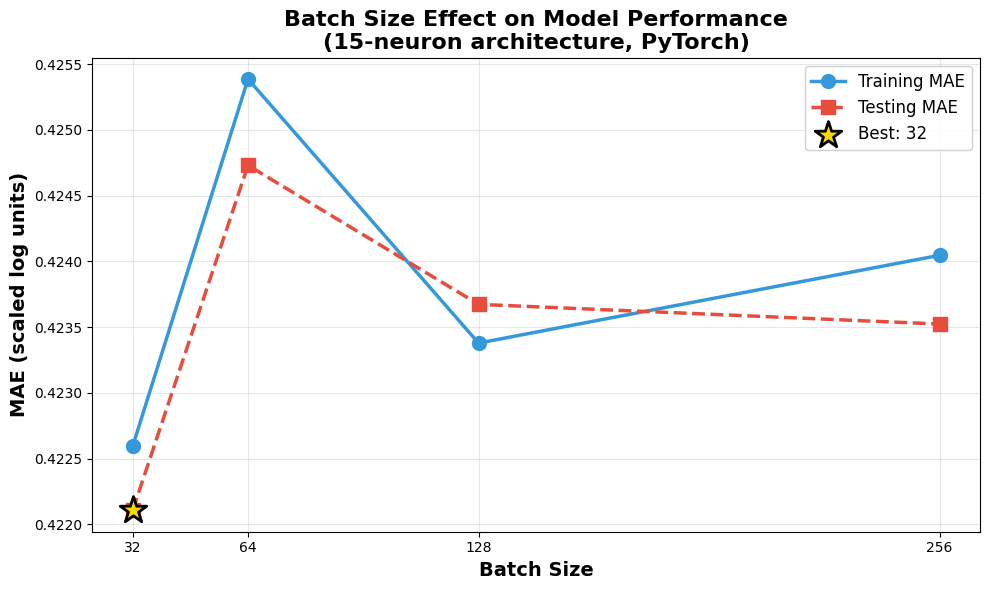


✓ Plot saved: assignments/3/batch_size_analysis.png
✓ Batch size analysis completed!


In [12]:
# Phase 2.1: Batch Size Analysis
print("="*80)
print("PHASE 2.1: BATCH SIZE ANALYSIS")
print("="*80)

batch_sizes = [32, 64, 128, 256]
batch_results = {'batch_size': [], 'train_mae': [], 'test_mae': [], 'epochs_trained': []}

print(f"\nTesting {len(batch_sizes)} different batch sizes...")
print(f"Architecture: 15 neurons per hidden layer")
print(f"Epochs: 100 (with early stopping patience=10)")
print(f"Learning rate: 0.001")
print(f"Dropout: 0.0 (no dropout)\n")

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

for batch_size in tqdm(batch_sizes, desc="Batch size tuning"):
    print(f"\n{'='*60}")
    print(f"Testing batch size: {batch_size}")
    print(f"{'='*60}")
    
    # Create model
    model, optimizer, criterion = create_ann_model(
        input_dim, output_dim,
        hidden_neurons=15,
        learning_rate=0.001,
        dropout_rate=0.0
    )
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    generator = torch.Generator().manual_seed(42)
    train_subset, val_subset = torch.utils.data.random_split(
        train_dataset, [train_size, val_size], generator=generator
    )
    
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    
    # Training with early stopping
    print("Training...")
    best_val_loss, epochs_trained = train_with_early_stopping(
        model, optimizer, criterion,
        train_loader, val_loader,
        max_epochs=100,
        patience=10,
        device=device
    )
    
    # Evaluate
    train_pred = get_predictions(model, X_train_tensor, batch_size=2048, device=device)
    test_pred = get_predictions(model, X_test_tensor, batch_size=2048, device=device)
    
    train_mae = mean_absolute_error(y_train_scaled, train_pred)
    test_mae = mean_absolute_error(y_test_scaled, test_pred)
    
    batch_results['batch_size'].append(batch_size)
    batch_results['train_mae'].append(train_mae)
    batch_results['test_mae'].append(test_mae)
    batch_results['epochs_trained'].append(epochs_trained)
    
    print(f"✓ Completed in {epochs_trained} epochs")
    print(f"  Train MAE: {train_mae:.4f}")
    print(f"  Test MAE:  {test_mae:.4f}")
    print(f"  Gap: {abs(test_mae - train_mae):.4f}")

# Find best batch size
best_idx = np.argmin(batch_results['test_mae'])
best_batch_size = batch_results['batch_size'][best_idx]
best_test_mae = batch_results['test_mae'][best_idx]

print(f"\n{'='*80}")
print(f"BATCH SIZE ANALYSIS - RESULTS")
print(f"{'='*80}")
print(f"Best batch size: {best_batch_size}")
print(f"Best test MAE: {best_test_mae:.4f}")
print(f"{'='*80}")

# Plot results
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(batch_results['batch_size'], batch_results['train_mae'], 
        marker='o', linestyle='-', linewidth=2.5, markersize=10, 
        label='Training MAE', color='#3498DB')
ax.plot(batch_results['batch_size'], batch_results['test_mae'], 
        marker='s', linestyle='--', linewidth=2.5, markersize=10, 
        label='Testing MAE', color='#E74C3C')

# Mark best point
ax.scatter([best_batch_size], [best_test_mae], s=400, c='gold', marker='*', 
          edgecolors='black', linewidth=2, zorder=5, 
          label=f'Best: {best_batch_size}')

ax.set_xlabel('Batch Size', fontsize=14, fontweight='bold')
ax.set_ylabel('MAE (scaled log units)', fontsize=14, fontweight='bold')
ax.set_title('Batch Size Effect on Model Performance\n(15-neuron architecture, PyTorch)', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xticks(batch_sizes)

plt.tight_layout()
plot_path = os.path.join(plots_dir, 'batch_size_analysis.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved: {plot_path}")
print(f"✓ Batch size analysis completed!")


PHASE 2.2: LEARNING RATE ANALYSIS

Testing 5 learning rates with 2 dropout configurations...
Architecture: 15 neurons per hidden layer
Batch size: 32 (from Phase 2.1)
Epochs: 100 (with early stopping patience=10)
Dropout configs: 0.05 (with) vs 0.0 (without)



Learning rate tuning:   0%|          | 0/5 [00:00<?, ?it/s]


Testing learning rate: 0.0001
  → Testing with dropout (0.05)...
     Train MAE: 0.4277, Test MAE: 0.4272
  → Testing without dropout...


Learning rate tuning:  20%|██        | 1/5 [07:04<28:17, 424.31s/it]

     Train MAE: 0.4253, Test MAE: 0.4250

Testing learning rate: 0.0005
  → Testing with dropout (0.05)...
     Train MAE: 0.4220, Test MAE: 0.4224
  → Testing without dropout...


...

     Train MAE: 0.4173, Test MAE: 0.4178

Testing learning rate: 0.005
  → Testing with dropout (0.05)...
     Train MAE: 0.4238, Test MAE: 0.4241
  → Testing without dropout...


Learning rate tuning:  80%|████████  | 4/5 [19:04<04:10, 250.56s/it]

     Train MAE: 0.4199, Test MAE: 0.4195

Testing learning rate: 0.01
  → Testing with dropout (0.05)...
     Train MAE: 0.4319, Test MAE: 0.4316
  → Testing without dropout...


Learning rate tuning: 100%|██████████| 5/5 [21:05<00:00, 253.07s/it]

     Train MAE: 0.4249, Test MAE: 0.4250

LEARNING RATE ANALYSIS - RESULTS
Best learning rate: 0.001
Best test MAE: 0.4178 (without dropout)


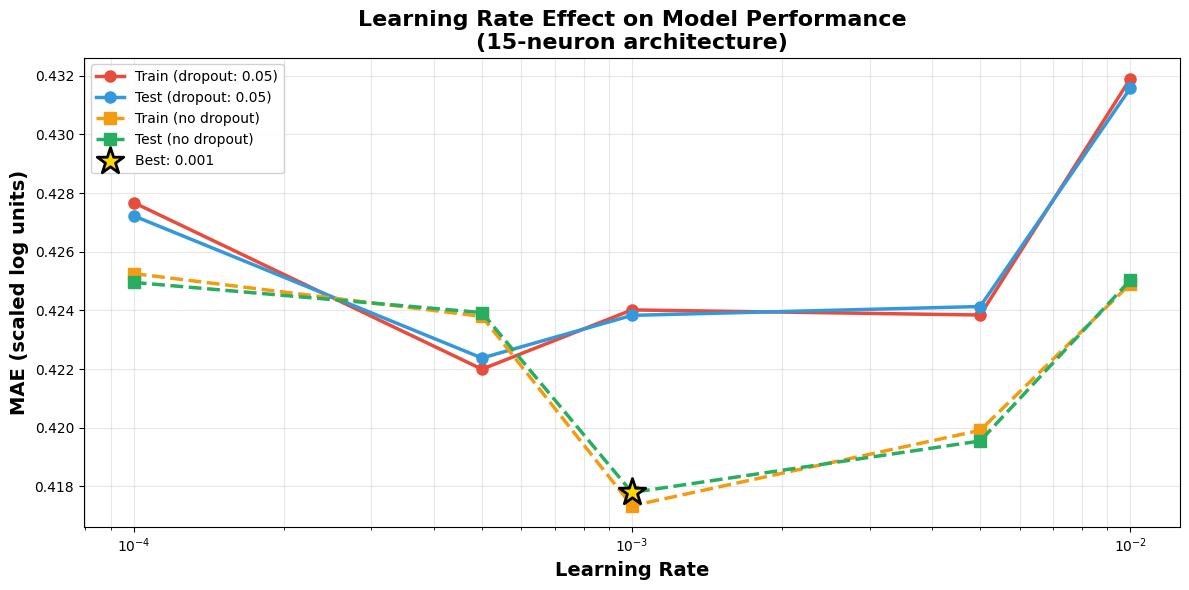


✓ Plot saved: assignments/3/learning_rate_analysis.png
✓ Learning rate analysis completed!


In [13]:
# Phase 2.2: Learning Rate Analysis (with and without dropout)
print("="*80)
print("PHASE 2.2: LEARNING RATE ANALYSIS")
print("="*80)

learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01]
lr_results = {
    'learning_rate': [],
    'train_mae_dropout': [],
    'test_mae_dropout': [],
    'train_mae_no_dropout': [],
    'test_mae_no_dropout': []
}

print(f"\nTesting {len(learning_rates)} learning rates with 2 dropout configurations...")
print(f"Architecture: 15 neurons per hidden layer")
print(f"Batch size: {best_batch_size} (from Phase 2.1)")
print(f"Epochs: 100 (with early stopping patience=10)")
print(f"Dropout configs: 0.05 (with) vs 0.0 (without)\n")

# Reuse tensors from Phase 2.1 (or recreate if needed)
if 'X_train_tensor' not in locals():
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Fixed train/val split for fair comparison
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size], generator=generator
 )
train_loader = DataLoader(train_subset, batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=best_batch_size, shuffle=False)

for lr in tqdm(learning_rates, desc="Learning rate tuning"):
    print(f"\n{'='*60}")
    print(f"Testing learning rate: {lr}")
    print(f"{'='*60}")
    
    # WITH DROPOUT (0.05)
    print("  → Testing with dropout (0.05)...")
    model_dropout, optimizer_dropout, criterion_dropout = create_ann_model(
        input_dim, output_dim,
        hidden_neurons=15,
        learning_rate=lr,
        dropout_rate=0.05
    )
    best_val_loss_d, epochs_trained_d = train_with_early_stopping(
        model_dropout, optimizer_dropout, criterion_dropout,
        train_loader, val_loader,
        max_epochs=100,
        patience=10,
        device=device
    )
    train_pred_d = get_predictions(model_dropout, X_train_tensor, batch_size=2048, device=device)
    test_pred_d = get_predictions(model_dropout, X_test_tensor, batch_size=2048, device=device)
    train_mae_d = mean_absolute_error(y_train_scaled, train_pred_d)
    test_mae_d = mean_absolute_error(y_test_scaled, test_pred_d)
    print(f"     Train MAE: {train_mae_d:.4f}, Test MAE: {test_mae_d:.4f}")
    
    # WITHOUT DROPOUT (0.0)
    print("  → Testing without dropout...")
    model_no_dropout, optimizer_no_dropout, criterion_no_dropout = create_ann_model(
        input_dim, output_dim,
        hidden_neurons=15,
        learning_rate=lr,
        dropout_rate=0.0
    )
    best_val_loss_nd, epochs_trained_nd = train_with_early_stopping(
        model_no_dropout, optimizer_no_dropout, criterion_no_dropout,
        train_loader, val_loader,
        max_epochs=100,
        patience=10,
        device=device
    )
    train_pred_nd = get_predictions(model_no_dropout, X_train_tensor, batch_size=2048, device=device)
    test_pred_nd = get_predictions(model_no_dropout, X_test_tensor, batch_size=2048, device=device)
    train_mae_nd = mean_absolute_error(y_train_scaled, train_pred_nd)
    test_mae_nd = mean_absolute_error(y_test_scaled, test_pred_nd)
    print(f"     Train MAE: {train_mae_nd:.4f}, Test MAE: {test_mae_nd:.4f}")
    
    lr_results['learning_rate'].append(lr)
    lr_results['train_mae_dropout'].append(train_mae_d)
    lr_results['test_mae_dropout'].append(test_mae_d)
    lr_results['train_mae_no_dropout'].append(train_mae_nd)
    lr_results['test_mae_no_dropout'].append(test_mae_nd)

# Find best configuration (no dropout)
best_lr_idx = np.argmin(lr_results['test_mae_no_dropout'])
best_lr = lr_results['learning_rate'][best_lr_idx]
best_lr_mae = lr_results['test_mae_no_dropout'][best_lr_idx]

print(f"\n{'='*80}")
print(f"LEARNING RATE ANALYSIS - RESULTS")
print(f"{'='*80}")
print(f"Best learning rate: {best_lr}")
print(f"Best test MAE: {best_lr_mae:.4f} (without dropout)")
print(f"{'='*80}")

# Plot results
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(lr_results['learning_rate'], lr_results['train_mae_dropout'], 
        marker='o', linestyle='-', linewidth=2.5, markersize=8, 
        label='Train (dropout: 0.05)', color='#E74C3C')
ax.plot(lr_results['learning_rate'], lr_results['test_mae_dropout'], 
        marker='o', linestyle='-', linewidth=2.5, markersize=8, 
        label='Test (dropout: 0.05)', color='#3498DB')
ax.plot(lr_results['learning_rate'], lr_results['train_mae_no_dropout'], 
        marker='s', linestyle='--', linewidth=2.5, markersize=8, 
        label='Train (no dropout)', color='#F39C12')
ax.plot(lr_results['learning_rate'], lr_results['test_mae_no_dropout'], 
        marker='s', linestyle='--', linewidth=2.5, markersize=8, 
        label='Test (no dropout)', color='#27AE60')

# Mark best point
ax.scatter([best_lr], [best_lr_mae], s=400, c='gold', marker='*', 
          edgecolors='black', linewidth=2, zorder=5, 
          label=f'Best: {best_lr}')

ax.set_xlabel('Learning Rate', fontsize=14, fontweight='bold')
ax.set_ylabel('MAE (scaled log units)', fontsize=14, fontweight='bold')
ax.set_title('Learning Rate Effect on Model Performance\n(15-neuron architecture)', 
            fontsize=16, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=10, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plot_path = os.path.join(plots_dir, 'learning_rate_analysis.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved: {plot_path}")
print(f"✓ Learning rate analysis completed!")


PHASE 2.3: ARCHITECTURE VALIDATION

Testing 6 different architectures...
Batch size: 32 (from Phase 2.1)
Learning rate: 0.001 (from Phase 2.2)
Dropout: 0.0 (no dropout)
Epochs: 100 (with early stopping patience=15)



Architecture validation:   0%|          | 0/6 [00:00<?, ?it/s]


Testing 5 neurons per layer
  Total parameters: 612


Architecture validation:  17%|█▋        | 1/6 [03:27<17:19, 208.00s/it]

✓ Minimum validation MSE: 0.314674
✓ Test MAE: 0.4367
✓ Training time: 208.0s
✓ Samples/parameter ratio: 71.7:1

Testing 8 neurons per layer
  Total parameters: 948


...

✓ Minimum validation MSE: 0.296276
✓ Test MAE: 0.4190
✓ Training time: 220.6s
✓ Samples/parameter ratio: 30.8:1

Testing 15 neurons per layer
  Total parameters: 1,802


Architecture validation:  83%|████████▎ | 5/6 [16:10<03:15, 195.12s/it]

✓ Minimum validation MSE: 0.290619
✓ Test MAE: 0.4152
✓ Training time: 179.3s
✓ Samples/parameter ratio: 24.4:1

Testing 20 neurons per layer
  Total parameters: 2,472


Architecture validation: 100%|██████████| 6/6 [19:15<00:00, 192.65s/it]

✓ Minimum validation MSE: 0.288066
✓ Test MAE: 0.4128
✓ Training time: 184.8s
✓ Samples/parameter ratio: 17.8:1

ARCHITECTURE VALIDATION - RESULTS
Best configuration: 20 neurons per layer
  Total parameters: 2,472
  Validation MSE: 0.288066
  Test MAE: 0.4128
  Training time: 184.8s
  Samples/parameter ratio: 17.8:1


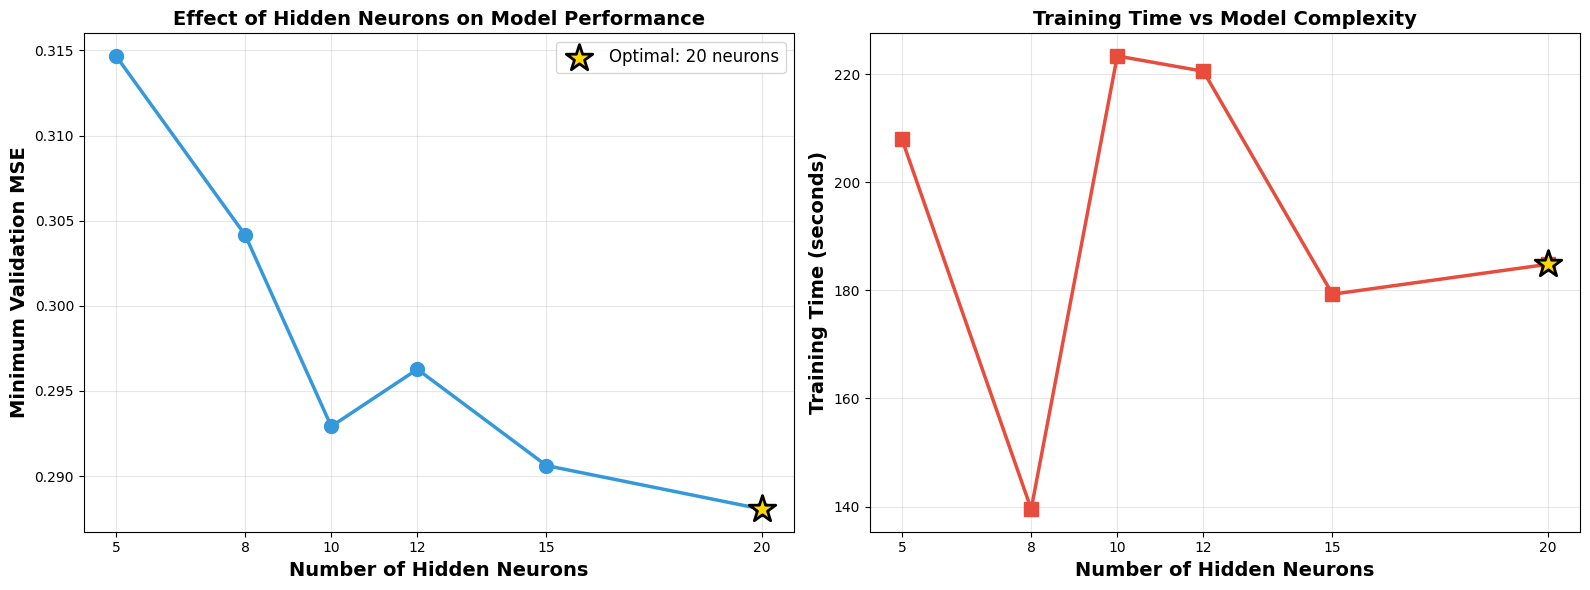


✓ Plot saved: assignments/3/hidden_neurons_analysis.png
✓ Architecture validation completed!

⭐ Optimal configuration found: 20 neurons per hidden layer!


In [14]:
# Phase 2.3: Architecture Validation (Hidden Neurons)
print("="*80)
print("PHASE 2.3: ARCHITECTURE VALIDATION")
print("="*80)

hidden_neurons_list = [5, 8, 10, 12, 15, 20]
hidden_results = {
    'hidden_neurons': [], 
    'parameters': [],
    'min_val_mse': [], 
    'test_mae': [], 
    'train_time': []
}

print(f"\nTesting {len(hidden_neurons_list)} different architectures...")
print(f"Batch size: {best_batch_size} (from Phase 2.1)")
print(f"Learning rate: {best_lr} (from Phase 2.2)")
print(f"Dropout: 0.0 (no dropout)")
print(f"Epochs: 100 (with early stopping patience=15)\n")

# Reuse tensors from previous phases (or recreate if needed)
if 'X_train_tensor' not in locals():
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Fixed train/val split for fair comparison
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size], generator=generator
 )
train_loader = DataLoader(train_subset, batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=best_batch_size, shuffle=False)

for n_neurons in tqdm(hidden_neurons_list, desc="Architecture validation"):
    print(f"\n{'='*60}")
    print(f"Testing {n_neurons} neurons per layer")
    print(f"{'='*60}")
    
    # Calculate parameters for this architecture
    # Layer 1: input_dim * n_neurons + n_neurons (bias)
    # Layer 2: n_neurons * n_neurons + n_neurons (bias)
    # Layer 3: n_neurons * output_dim + output_dim (bias)
    params = (input_dim * n_neurons + n_neurons) + \
             (n_neurons * n_neurons + n_neurons) + \
             (n_neurons * output_dim + output_dim)
    print(f"  Total parameters: {params:,}")
    
    model, optimizer, criterion = create_ann_model(
        input_dim, output_dim,
        hidden_neurons=n_neurons,
        learning_rate=best_lr,
        dropout_rate=0.0
    )
    
    # Time the training
    start_time = time.time()
    best_val_loss, epochs_trained = train_with_early_stopping(
        model, optimizer, criterion,
        train_loader, val_loader,
        max_epochs=100,
        patience=15,
        device=device
    )
    train_time = time.time() - start_time
    
    # Get metrics
    test_pred = get_predictions(model, X_test_tensor, batch_size=2048, device=device)
    test_mae = mean_absolute_error(y_test_scaled, test_pred)
    
    hidden_results['hidden_neurons'].append(n_neurons)
    hidden_results['parameters'].append(params)
    hidden_results['min_val_mse'].append(best_val_loss)
    hidden_results['test_mae'].append(test_mae)
    hidden_results['train_time'].append(train_time)
    
    print(f"✓ Minimum validation MSE: {best_val_loss:.6f}")
    print(f"✓ Test MAE: {test_mae:.4f}")
    print(f"✓ Training time: {train_time:.1f}s")
    print(f"✓ Samples/parameter ratio: {X_train_scaled.shape[0]/params:.1f}:1")

# Find best configuration
best_idx = np.argmin(hidden_results['test_mae'])
best_neurons = hidden_results['hidden_neurons'][best_idx]
best_params = hidden_results['parameters'][best_idx]
best_mse = hidden_results['min_val_mse'][best_idx]
best_mae = hidden_results['test_mae'][best_idx]

print(f"\n{'='*80}")
print(f"ARCHITECTURE VALIDATION - RESULTS")
print(f"{'='*80}")
print(f"Best configuration: {best_neurons} neurons per layer")
print(f"  Total parameters: {best_params:,}")
print(f"  Validation MSE: {best_mse:.6f}")
print(f"  Test MAE: {best_mae:.4f}")
print(f"  Training time: {hidden_results['train_time'][best_idx]:.1f}s")
print(f"  Samples/parameter ratio: {X_train_scaled.shape[0]/best_params:.1f}:1")
print(f"{'='*80}")

# Plot results - two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: MSE vs Neurons
ax1.plot(hidden_results['hidden_neurons'], hidden_results['min_val_mse'], 
        marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#3498DB')
ax1.scatter([best_neurons], [best_mse], s=400, c='gold', marker='*', 
           zorder=5, edgecolors='black', linewidth=2, 
           label=f'Optimal: {best_neurons} neurons')
ax1.set_xlabel('Number of Hidden Neurons', fontsize=14, fontweight='bold')
ax1.set_ylabel('Minimum Validation MSE', fontsize=14, fontweight='bold')
ax1.set_title('Effect of Hidden Neurons on Model Performance', 
             fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(hidden_neurons_list)
ax1.legend(fontsize=12)

# Plot 2: Training time vs Neurons
ax2.plot(hidden_results['hidden_neurons'], hidden_results['train_time'], 
        marker='s', linestyle='-', linewidth=2.5, markersize=10, color='#E74C3C')
ax2.scatter([best_neurons], [hidden_results['train_time'][best_idx]], 
           s=400, c='gold', marker='*', zorder=5, 
           edgecolors='black', linewidth=2)
ax2.set_xlabel('Number of Hidden Neurons', fontsize=14, fontweight='bold')
ax2.set_ylabel('Training Time (seconds)', fontsize=14, fontweight='bold')
ax2.set_title('Training Time vs Model Complexity', 
             fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(hidden_neurons_list)

plt.tight_layout()
plot_path = os.path.join(plots_dir, 'hidden_neurons_analysis.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved: {plot_path}")
print(f"✓ Architecture validation completed!")
print(f"\n⭐ Optimal configuration found: {best_neurons} neurons per hidden layer!")


FINAL MODEL TRAINING WITH OPTIMAL HYPERPARAMETERS

Training final model with optimal configuration:
  - Hidden neurons: 20
  - Learning rate: 0.001
  - Batch size: 32
  - Dropout: 0.0
  - Max epochs: 150
  - Early stopping patience: 10
  - Training samples: 43,906
  - Validation samples: 8,781

Training final model...


Training:   0%|          | 0/150 [00:00<?, ?it/s]

Training:  65%|██████▌   | 98/150 [03:50<02:02,  2.36s/it]



✓ Training completed in 99 epochs
✓ Best validation loss: 0.286002
✓ Final training loss: 0.277216
✓ Model saved: assignments/3/final_model_best.pth

Generating predictions...
✓ PGA R² score: 0.7143
✓ PGV R² score: 0.7911

Creating training history plot...


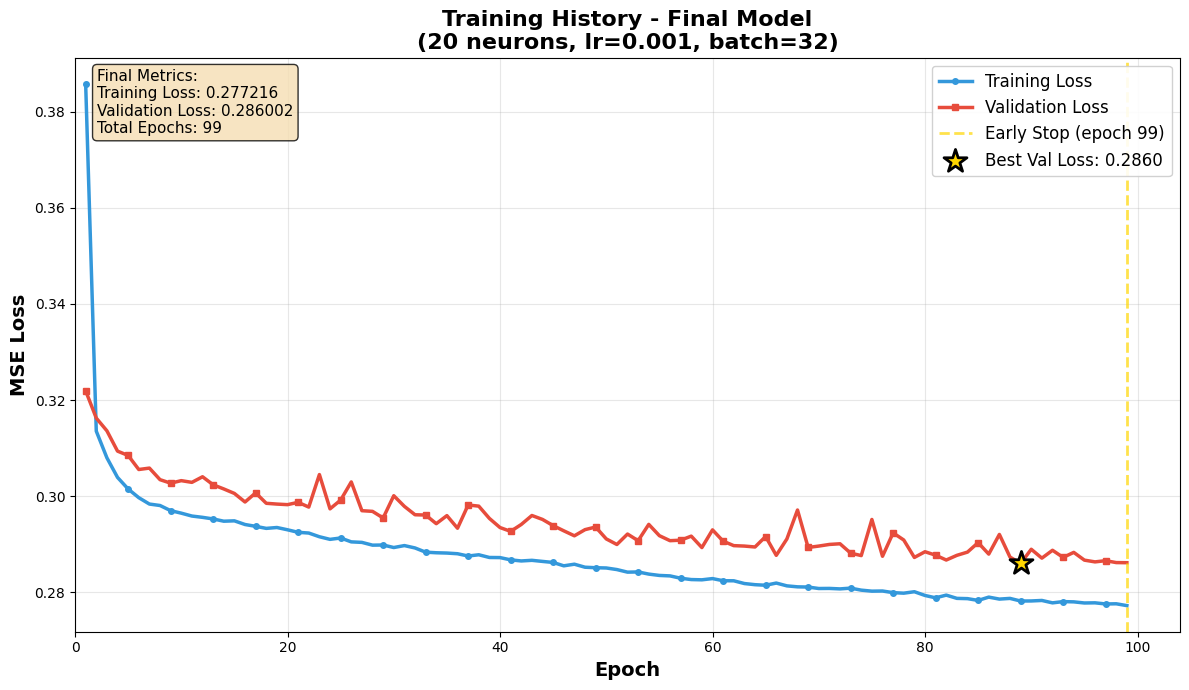

✓ Training history saved: assignments/3/training_history.png
Creating PGA/PGV validation plots...


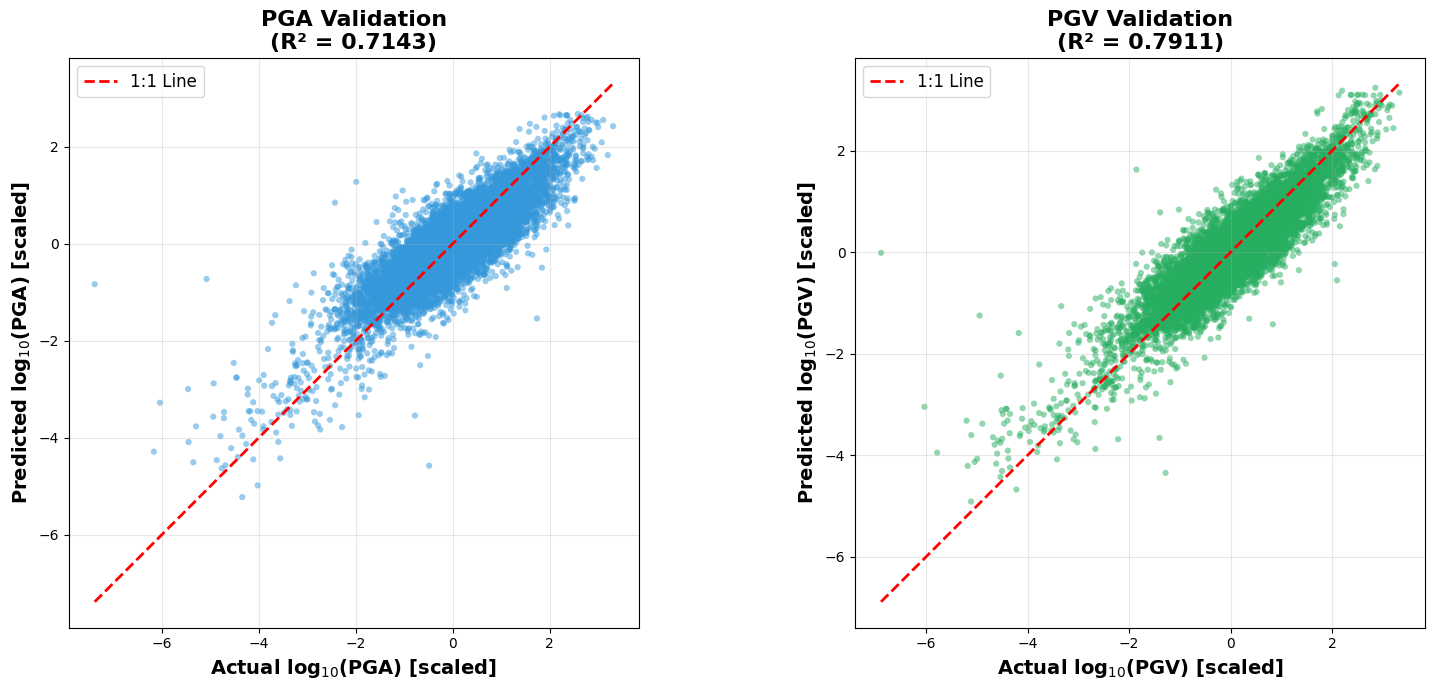

✓ PGA/PGV validation saved: assignments/3/best_model_pga_pgv_validation.png

FINAL MODEL TRAINING COMPLETED!


In [16]:
# Phase 2.4 & 3: Final Model Training with Validation
print("="*80)
print("FINAL MODEL TRAINING WITH OPTIMAL HYPERPARAMETERS")
print("="*80)

print(f"\nTraining final model with optimal configuration:")
print(f"  - Hidden neurons: {best_neurons}")
print(f"  - Learning rate: {best_lr}")
print(f"  - Batch size: {best_batch_size}")
print(f"  - Dropout: 0.0")
print(f"  - Max epochs: 150")
print(f"  - Early stopping patience: 10")
print(f"  - Training samples: {X_train_scaled.shape[0]:,}")
print(f"  - Validation samples: {int(X_train_scaled.shape[0] * 0.2):,}\n")

# Create final model
final_model, final_optimizer, final_criterion = create_ann_model(
    input_dim, output_dim,
    hidden_neurons=best_neurons,
    learning_rate=best_lr,
    dropout_rate=0.0
)

# Prepare data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size], generator=generator
)
train_loader = DataLoader(train_subset, batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=best_batch_size, shuffle=False)

# Training with history tracking
print("Training final model...")
best_val_loss = float('inf')
patience_counter = 0
patience = 10
epochs_trained = 0
best_state = copy.deepcopy(final_model.state_dict())

training_history = {
    'train_loss': [],
    'val_loss': [],
    'epochs': []
}

for epoch in tqdm(range(150), desc="Training"):
    # Training phase
    final_model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        final_optimizer.zero_grad()
        outputs = final_model(X_batch)
        loss = final_criterion(outputs, y_batch)
        loss.backward()
        final_optimizer.step()
        train_losses.append(loss.item())
    
    avg_train_loss = float(np.mean(train_losses))
    
    # Validation phase
    final_model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = final_model(X_batch)
            val_loss = final_criterion(outputs, y_batch)
            val_losses.append(val_loss.item())
    
    avg_val_loss = float(np.mean(val_losses))
    epochs_trained = epoch + 1
    
    # Store history
    training_history['train_loss'].append(avg_train_loss)
    training_history['val_loss'].append(avg_val_loss)
    training_history['epochs'].append(epochs_trained)
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_state = copy.deepcopy(final_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            break

# Load best weights
final_model.load_state_dict(best_state)

print(f"\n✓ Training completed in {epochs_trained} epochs")
print(f"✓ Best validation loss: {best_val_loss:.6f}")
print(f"✓ Final training loss: {training_history['train_loss'][-1]:.6f}")

# Save model
model_path = os.path.join(plots_dir, 'final_model_best.pth')
torch.save({
    'epoch': epochs_trained,
    'model_state_dict': final_model.state_dict(),
    'optimizer_state_dict': final_optimizer.state_dict(),
    'train_loss': training_history['train_loss'][-1],
    'val_loss': best_val_loss,
    'best_neurons': best_neurons,
    'best_lr': best_lr,
    'best_batch_size': best_batch_size,
}, model_path)
print(f"✓ Model saved: {model_path}")

# Generate predictions on test set
print("\nGenerating predictions...")
y_test_pred_scaled = get_predictions(final_model, X_test_tensor, batch_size=2048, device=device)

# Extract PGA and PGV predictions
pga_actual = y_test_scaled[:, 0]
pga_pred = y_test_pred_scaled[:, 0]
pgv_actual = y_test_scaled[:, 1]
pgv_pred = y_test_pred_scaled[:, 1]

r2_pga = r2_score(pga_actual, pga_pred)
r2_pgv = r2_score(pgv_actual, pgv_pred)

print(f"✓ PGA R² score: {r2_pga:.4f}")
print(f"✓ PGV R² score: {r2_pgv:.4f}")

# Plot 1: Training History
print("\nCreating training history plot...")
fig1, ax = plt.subplots(1, 1, figsize=(12, 7))

epochs_range = training_history['epochs']
ax.plot(epochs_range, training_history['train_loss'], 
        linewidth=2.5, label='Training Loss', color='#3498DB', marker='o', 
        markersize=4, markevery=max(1, len(epochs_range)//20))
ax.plot(epochs_range, training_history['val_loss'], 
        linewidth=2.5, label='Validation Loss', color='#E74C3C', marker='s', 
        markersize=4, markevery=max(1, len(epochs_range)//20))

ax.axvline(x=epochs_trained, color='gold', linestyle='--', linewidth=2, 
          label=f'Early Stop (epoch {epochs_trained})', alpha=0.7)

best_epoch = training_history['val_loss'].index(best_val_loss) + 1
ax.scatter([best_epoch], [best_val_loss], s=300, c='gold', marker='*', 
          edgecolors='black', linewidth=2, zorder=5, 
          label=f'Best Val Loss: {best_val_loss:.4f}')

ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax.set_ylabel('MSE Loss', fontsize=14, fontweight='bold')
ax.set_title(f'Training History - Final Model\n({best_neurons} neurons, lr={best_lr}, batch={best_batch_size})', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(epochs_range) + 5)

textstr = f'Final Metrics:\n'
textstr += f'Training Loss: {training_history["train_loss"][-1]:.6f}\n'
textstr += f'Validation Loss: {best_val_loss:.6f}\n'
textstr += f'Total Epochs: {epochs_trained}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', bbox=props)

plt.tight_layout()
plot_path = os.path.join(plots_dir, 'training_history.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Training history saved: {plot_path}")

# Plot 2: PGA & PGV Validation
print("Creating PGA/PGV validation plots...")
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# PGA
ax1.scatter(pga_actual, pga_pred, alpha=0.5, s=20, color='#3498DB', edgecolors='none')
min_val = min(pga_actual.min(), pga_pred.min())
max_val = max(pga_actual.max(), pga_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='1:1 Line')
ax1.set_xlabel('Actual log$_{10}$(PGA) [scaled]', fontsize=14, fontweight='bold')
ax1.set_ylabel('Predicted log$_{10}$(PGA) [scaled]', fontsize=14, fontweight='bold')
ax1.set_title(f'PGA Validation\n(R² = {r2_pga:.4f})', fontsize=16, fontweight='bold')
ax1.legend(fontsize=12, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

# PGV
ax2.scatter(pgv_actual, pgv_pred, alpha=0.5, s=20, color='#27AE60', edgecolors='none')
min_val = min(pgv_actual.min(), pgv_pred.min())
max_val = max(pgv_actual.max(), pgv_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='1:1 Line')
ax2.set_xlabel('Actual log$_{10}$(PGV) [scaled]', fontsize=14, fontweight='bold')
ax2.set_ylabel('Predicted log$_{10}$(PGV) [scaled]', fontsize=14, fontweight='bold')
ax2.set_title(f'PGV Validation\n(R² = {r2_pgv:.4f})', fontsize=16, fontweight='bold')
ax2.legend(fontsize=12, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plot_path = os.path.join(plots_dir, 'best_model_pga_pgv_validation.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ PGA/PGV validation saved: {plot_path}")

print("\n" + "="*80)
print("FINAL MODEL TRAINING COMPLETED!")
print("="*80)

# Phase 4: Model Evaluation & Residual Analysis

Load the saved model and perform comprehensive evaluation including:
- Overall performance metrics (R², MAE, RMSE, MAPE)
- Residual analysis and distribution
- Error analysis across all outputs

In [23]:
# Phase 4.1: Load Trained Model and Generate Predictions
print("="*80)
print("PHASE 4: MODEL EVALUATION & RESIDUAL ANALYSIS")
print("="*80)

# Load the saved model
model_path = os.path.join(plots_dir, 'final_model_best.pth')
print(f"\nLoading trained model from: {model_path}")

checkpoint = torch.load(model_path)
print(f"✓ Model checkpoint loaded")
print(f"  - Training epoch: {checkpoint['epoch']}")
print(f"  - Training loss: {checkpoint['train_loss']:.6f}")
print(f"  - Validation loss: {checkpoint['val_loss']:.6f}")
print(f"  - Hidden neurons: {checkpoint['best_neurons']}")
print(f"  - Learning rate: {checkpoint['best_lr']}")
print(f"  - Batch size: {checkpoint['best_batch_size']}")

# Recreate model architecture
eval_model = ANNModel(input_dim, output_dim, 
                      hidden_neurons=checkpoint['best_neurons'], 
                      dropout_rate=0.0).to(device)
eval_model.load_state_dict(checkpoint['model_state_dict'])
eval_model.eval()
print(f"✓ Model architecture recreated and weights loaded")

# Generate predictions on both train and test sets
print(f"\nGenerating predictions...")
with torch.no_grad():
    y_train_pred_scaled = get_predictions(eval_model, X_train_tensor, batch_size=2048, device=device)
    y_test_pred_scaled = get_predictions(eval_model, X_test_tensor, batch_size=2048, device=device)

print(f"✓ Train predictions: {y_train_pred_scaled.shape}")
print(f"✓ Test predictions: {y_test_pred_scaled.shape}")

# Compute comprehensive metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def compute_metrics(y_true, y_pred):
    """Compute comprehensive regression metrics"""
    metrics = {}
    metrics['mae'] = mean_absolute_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics['r2'] = r2_score(y_true, y_pred)
    # Mean Absolute Percentage Error (handle zeros)
    epsilon = 1e-10
    metrics['mape'] = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    return metrics

# Overall metrics
train_metrics = compute_metrics(y_train_scaled, y_train_pred_scaled)
test_metrics = compute_metrics(y_test_scaled, y_test_pred_scaled)

print(f"\n{'='*80}")
print(f"OVERALL PERFORMANCE METRICS (SCALED SPACE)")
print(f"{'='*80}")
print(f"\nTraining Set:")
print(f"  MAE:  {train_metrics['mae']:.6f}")
print(f"  RMSE: {train_metrics['rmse']:.6f}")
print(f"  R²:   {train_metrics['r2']:.6f}")
print(f"  MAPE: {train_metrics['mape']:.2f}%")

print(f"\nTest Set:")
print(f"  MAE:  {test_metrics['mae']:.6f}")
print(f"  RMSE: {test_metrics['rmse']:.6f}")
print(f"  R²:   {test_metrics['r2']:.6f}")
print(f"  MAPE: {test_metrics['mape']:.2f}%")

# Per-output metrics for key parameters (PGA, PGV, selected Sa)
print(f"\n{'='*80}")
print(f"PER-OUTPUT PERFORMANCE (TEST SET)")
print(f"{'='*80}")

output_names = ['PGA', 'PGV'] + [f'Sa(T={period_to_float(col):.3f}s)' 
                                  for col in selected_period_cols_sorted]

# Show metrics for PGA, PGV, and first 5 spectral periods
print(f"\n{'Output':<25} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("-" * 60)
for i in range(min(7, len(output_names))):
    mae_i = mean_absolute_error(y_test_scaled[:, i], y_test_pred_scaled[:, i])
    rmse_i = np.sqrt(mean_squared_error(y_test_scaled[:, i], y_test_pred_scaled[:, i]))
    r2_i = r2_score(y_test_scaled[:, i], y_test_pred_scaled[:, i])
    print(f"{output_names[i]:<25} {mae_i:>10.4f} {rmse_i:>10.4f} {r2_i:>10.4f}")

print(f"\n✓ Detailed metrics computed for all {len(output_names)} outputs")
print("="*80)

PHASE 4: MODEL EVALUATION & RESIDUAL ANALYSIS

Loading trained model from: assignments/3/final_model_best.pth
✓ Model checkpoint loaded
  - Training epoch: 99
  - Training loss: 0.277216
  - Validation loss: 0.286002
  - Hidden neurons: 20
  - Learning rate: 0.001
  - Batch size: 32
✓ Model architecture recreated and weights loaded

Generating predictions...
✓ Train predictions: (43906, 92)
✓ Test predictions: (10977, 92)

OVERALL PERFORMANCE METRICS (SCALED SPACE)

Training Set:
  MAE:  0.410459
  RMSE: 0.527206
  R²:   0.722052
  MAPE: 482.33%

Test Set:
  MAE:  0.410192
  RMSE: 0.530097
  R²:   0.719910
  MAPE: 389.55%

PER-OUTPUT PERFORMANCE (TEST SET)

Output                           MAE       RMSE         R²
------------------------------------------------------------
PGA                           0.4113     0.5345     0.7143
PGV                           0.3543     0.4590     0.7911
Sa(T=0.010s)                  0.4118     0.5351     0.7136
Sa(T=0.020s)                  0.4129 


PHASE 4.2: BINNED RESIDUAL ANALYSIS

Residuals shape (PGA only): (10977,)
Magnitude range: 4.00 - 9.12
Distance range: 0.79 - 499.69 km
  Vs30: -0.1 - 2.7 m/s

Creating binned residual plots...

MAGNITUDE BINNING
Bins created: 14
Bin centers: [4.1706667 4.512     4.8533335 5.194667  5.5360003 5.8773336 6.2186666
 6.56      6.9013333 7.2426667 7.5839996 7.925333  8.266666  8.949333 ]
Bin means: [ 0.04085023 -0.04728217 -0.01597709 -0.0055257   0.016942    0.05223326
  0.04414877  0.047287   -0.02662933  0.01386176  0.11190238 -0.17121603
  0.19635701  0.72566515]
Bin stds: [0.6521098  0.6191839  0.6172759  0.5172519  0.576912   0.47981212
 0.5208248  0.52705336 0.5136866  0.5332107  0.47151226 0.73714375
 0.43641013 0.3437037 ]
Std range: 0.3437 - 0.7371


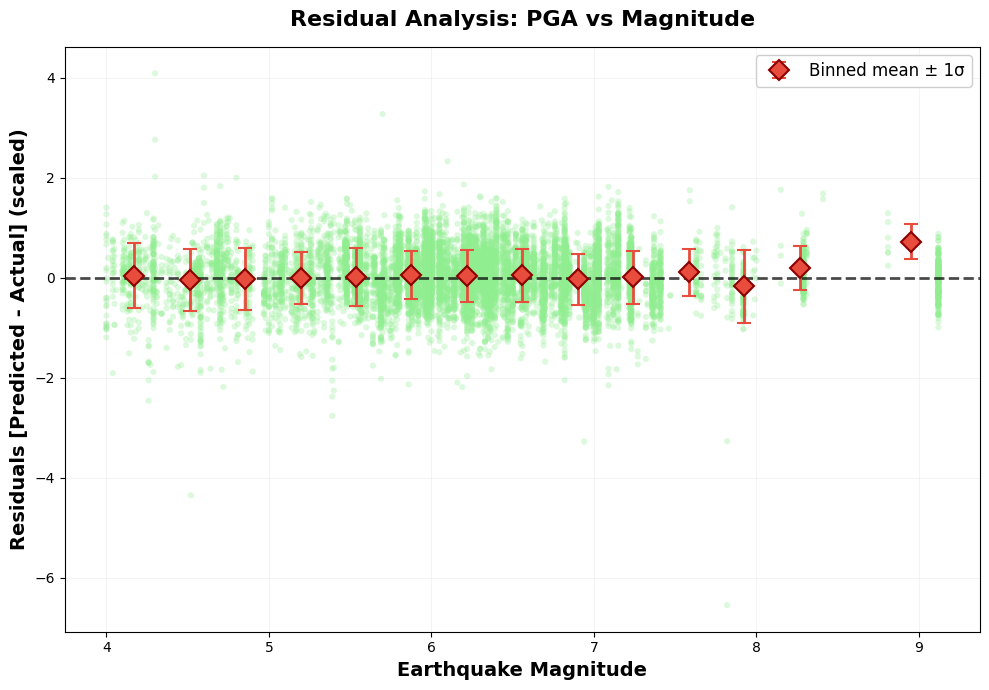

✓ Saved: assignments/3/residual_vs_magnitude.png

DISTANCE BINNING (LOG SCALE)
Bins created: 14
Bin centers: [  0.97407776   2.3035688    3.5424604    5.4476457    8.377465
  12.88298     19.811634    30.466602    46.851982    72.04962
 110.79889    170.38814    262.0252     402.94617   ]
Bin means: [ 0.23841254  0.27968568  0.03334631  0.24714291  0.09968713  0.06039789
 -0.01621636  0.08378698  0.04068172  0.01457013  0.02572337  0.04199872
  0.0031703   0.0009851 ]
Bin stds: [0.23992153 0.36523706 0.5964844  0.5926051  0.4572797  0.4596419
 0.53119355 0.49087077 0.5257593  0.51331425 0.5371037  0.51420957
 0.517135   0.595843  ]
Std range: 0.2399 - 0.5965


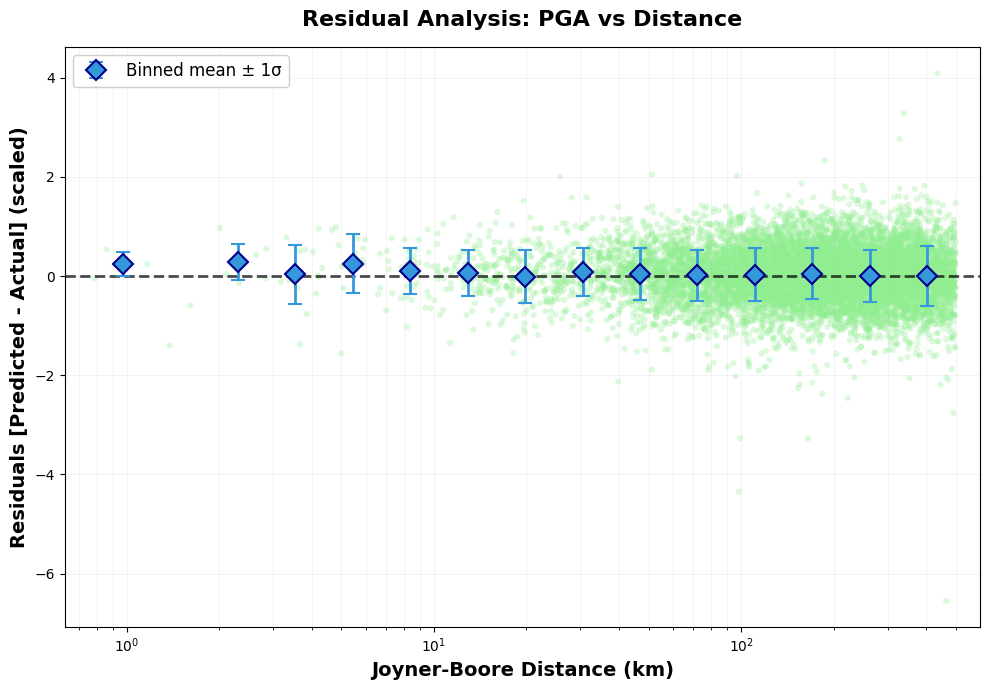

✓ Saved: assignments/3/residual_vs_distance.png

VS30 BINNING (LOG SCALE)
Bins created: 9
Bin centers: [0.33197194 0.42478234 0.54354    0.6954991  0.8899419  1.1387455
 1.4571081  1.8644761  2.3857331 ]
Bin means: [ 0.25848347  0.3079553  -0.03045263  0.26854065  0.05835268  0.04254018
  0.06875984  0.01644308  0.01814985]
Bin stds: [0.4255933  0.2614528  0.6606665  0.5759897  0.46006942 0.47938842
 0.51790756 0.5288656  0.5380196 ]
Std range: 0.2615 - 0.6607


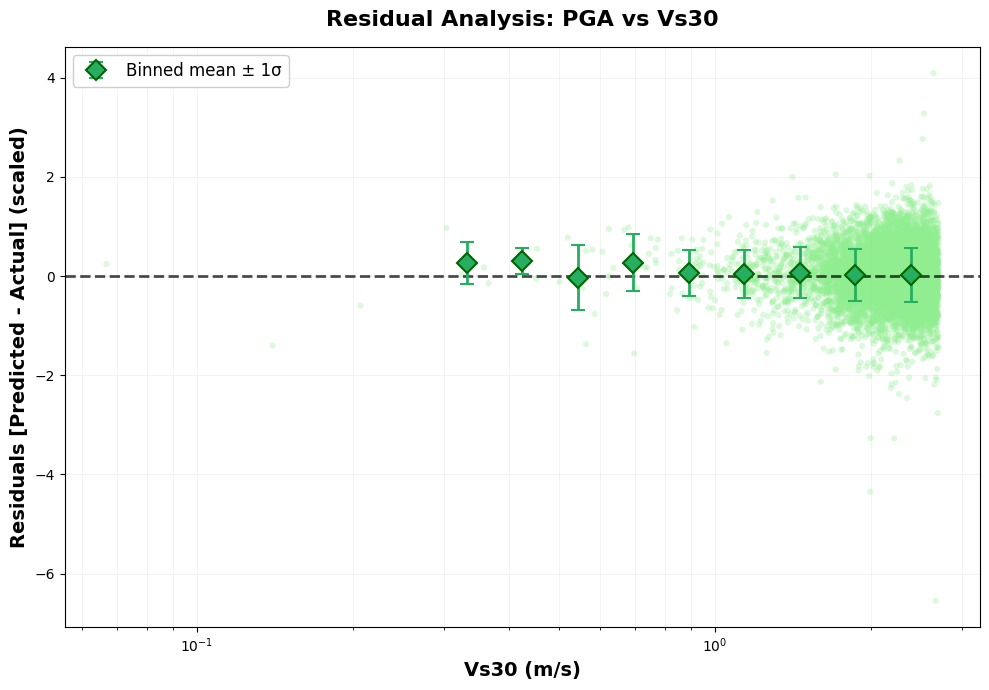

✓ Saved: assignments/3/residual_vs_vs30.png

BINNED RESIDUAL SUMMARY
Magnitude bins:
  Bins created: 14
  Bin range: 4.17 - 8.95
  Points per bin (avg): 766 (total: 10726)
  Std dev range: 0.3437 - 0.7371

Distance bins (log scale):
  Bins created: 14
  Bin range: 0.97 - 402.95 km
  Points per bin (avg): 784 (total: 10974)
  Std dev range: 0.2399 - 0.5965

Vs30 bins (log scale):
  Bins created: 9
  Bin range: 0.3 - 2.4 m/s
  Points per bin (avg): 1219 (total: 10971)
  Std dev range: 0.2615 - 0.6607

✓ PHASE 4.2 COMPLETE: Binned residual analysis with error bars


In [31]:
# Phase 4.2: Binned Residual Plot (Residuals vs. Predictor) with Mean ± Error Bars
print("\n" + "="*80)
print("PHASE 4.2: BINNED RESIDUAL ANALYSIS")
print("="*80)

# Create output directory for plots
plots_dir = 'assignments/3'
os.makedirs(plots_dir, exist_ok=True)

# Extract PGA residuals for analysis (index 0 is PGA)
residuals_test_pga = residuals_test[:, 0]  # Shape: (n_test,)

# Extract predictor variables from test set (UNSCALED for proper plotting)
# We need to inverse transform the scaled features
X_test_unscaled = scaler_X.inverse_transform(X_test_scaled)
magnitude_test = X_test_unscaled[:, 0]  # Earthquake_Magnitude
rjb_test = X_test_unscaled[:, 1]  # Rjb_km  
vs30_test = X_test_unscaled[:, 2]  # Vs30_Selected_for_Analysis_m_s

print(f"\nResiduals shape (PGA only): {residuals_test_pga.shape}")
print(f"Magnitude range: {magnitude_test.min():.2f} - {magnitude_test.max():.2f}")
print(f"Distance range: {rjb_test.min():.2f} - {rjb_test.max():.2f} km")
print(f"  Vs30: {vs30_test.min():.1f} - {vs30_test.max():.1f} m/s")

# Function to create binned residual data
def create_binned_residual_data(feature_values, residuals, n_bins=15, use_log=False):
    """Create binned residual data with mean and std"""
    # Remove any NaN or inf values
    valid_mask = np.isfinite(feature_values) & np.isfinite(residuals) & (feature_values > 0)
    feature_values = feature_values[valid_mask]
    residuals = residuals[valid_mask]
    
    if len(feature_values) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    
    # Create bins
    if use_log:
        # Use log-spaced bins
        log_min = np.log10(feature_values.min())
        log_max = np.log10(feature_values.max())
        bin_edges = np.logspace(log_min, log_max, n_bins + 1)
    else:
        # Use linear bins
        bin_edges = np.linspace(feature_values.min(), 
                                feature_values.max(), 
                                n_bins + 1)
    
    # Digitize data into bins
    bin_indices = np.digitize(feature_values, bin_edges)
    
    # Calculate statistics for each bin
    bin_centers = []
    bin_means = []
    bin_stds = []
    bin_counts = []
    
    for i in range(1, len(bin_edges)):
        mask = bin_indices == i
        count = mask.sum()
        if count > 2:  # Need at least 3 points for meaningful statistics
            # Use geometric mean for log-scaled bins, arithmetic mean for linear
            if use_log:
                # Geometric mean in log space
                bin_center = 10 ** ((np.log10(bin_edges[i-1]) + np.log10(bin_edges[i])) / 2)
            else:
                bin_center = (bin_edges[i-1] + bin_edges[i]) / 2
            
            bin_centers.append(bin_center)
            bin_means.append(residuals[mask].mean())
            bin_stds.append(residuals[mask].std())
            bin_counts.append(count)
    
    return (np.array(bin_centers), np.array(bin_means), 
            np.array(bin_stds), np.array(bin_counts))

print("\nCreating binned residual plots...")

# Plot 1: Residuals vs Magnitude
print("\n" + "="*60)
print("MAGNITUDE BINNING")
print("="*60)
bin_centers_mag, bin_means_mag, bin_stds_mag, bin_counts_mag = create_binned_residual_data(
    magnitude_test, residuals_test_pga, n_bins=15, use_log=False
)
print(f"Bins created: {len(bin_centers_mag)}")
if len(bin_centers_mag) > 0:
    print(f"Bin centers: {bin_centers_mag}")
    print(f"Bin means: {bin_means_mag}")
    print(f"Bin stds: {bin_stds_mag}")
    print(f"Std range: {bin_stds_mag.min():.4f} - {bin_stds_mag.max():.4f}")

fig1, ax1 = plt.subplots(1, 1, figsize=(10, 7))
# Scatter plot of all data - MORE VISIBLE like reference notebook
ax1.scatter(magnitude_test, residuals_test_pga, alpha=0.3, s=20, 
           color='lightgreen', edgecolors='none', rasterized=True, zorder=1)
# Binned means with ERROR BARS
if len(bin_centers_mag) > 0:
    ax1.errorbar(bin_centers_mag, bin_means_mag, yerr=bin_stds_mag, 
                fmt='D', markersize=10, capsize=5, capthick=2,
                color='#E74C3C', ecolor='#E74C3C', linewidth=2,
                markeredgecolor='darkred', markeredgewidth=1.5,
                label='Binned mean ± 1σ', zorder=10, alpha=1.0)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7, zorder=5)
ax1.set_xlabel('Earthquake Magnitude', fontsize=14, fontweight='bold')
ax1.set_ylabel('Residuals [Predicted - Actual] (scaled)', fontsize=14, fontweight='bold')
ax1.set_title('Residual Analysis: PGA vs Magnitude', fontsize=16, fontweight='bold', pad=15)
ax1.legend(fontsize=12, loc='best', framealpha=0.95)
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
x_range = magnitude_test.max() - magnitude_test.min()
ax1.set_xlim([magnitude_test.min() - 0.05*x_range, magnitude_test.max() + 0.05*x_range])
plt.tight_layout()
plot_path1 = os.path.join(plots_dir, 'residual_vs_magnitude.png')
plt.savefig(plot_path1, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {plot_path1}")

# Plot 2: Residuals vs Distance (log scale)
print("\n" + "="*60)
print("DISTANCE BINNING (LOG SCALE)")
print("="*60)
bin_centers_rjb, bin_means_rjb, bin_stds_rjb, bin_counts_rjb = create_binned_residual_data(
    rjb_test, residuals_test_pga, n_bins=15, use_log=True
)
print(f"Bins created: {len(bin_centers_rjb)}")
if len(bin_centers_rjb) > 0:
    print(f"Bin centers: {bin_centers_rjb}")
    print(f"Bin means: {bin_means_rjb}")
    print(f"Bin stds: {bin_stds_rjb}")
    print(f"Std range: {bin_stds_rjb.min():.4f} - {bin_stds_rjb.max():.4f}")

fig2, ax2 = plt.subplots(1, 1, figsize=(10, 7))
# Scatter plot of all data - MORE VISIBLE like reference notebook
ax2.scatter(rjb_test, residuals_test_pga, alpha=0.3, s=20, 
           color='lightgreen', edgecolors='none', rasterized=True, zorder=1)
# Binned means with ERROR BARS
if len(bin_centers_rjb) > 0:
    ax2.errorbar(bin_centers_rjb, bin_means_rjb, yerr=bin_stds_rjb, 
                fmt='D', markersize=10, capsize=5, capthick=2,
                color='#3498DB', ecolor='#3498DB', linewidth=2,
                markeredgecolor='darkblue', markeredgewidth=1.5,
                label='Binned mean ± 1σ', zorder=10, alpha=1.0)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7, zorder=5)
ax2.set_xlabel('Joyner-Boore Distance (km)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Residuals [Predicted - Actual] (scaled)', fontsize=14, fontweight='bold')
ax2.set_title('Residual Analysis: PGA vs Distance', fontsize=16, fontweight='bold', pad=15)
ax2.set_xscale('log')
ax2.legend(fontsize=12, loc='best', framealpha=0.95)
ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, which='both')
ax2.set_xlim([rjb_test.min() * 0.8, rjb_test.max() * 1.2])
plt.tight_layout()
plot_path2 = os.path.join(plots_dir, 'residual_vs_distance.png')
plt.savefig(plot_path2, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {plot_path2}")

# Plot 3: Residuals vs Vs30 (log scale)
print("\n" + "="*60)
print("VS30 BINNING (LOG SCALE)")
print("="*60)
bin_centers_vs30, bin_means_vs30, bin_stds_vs30, bin_counts_vs30 = create_binned_residual_data(
    vs30_test, residuals_test_pga, n_bins=15, use_log=True
)
print(f"Bins created: {len(bin_centers_vs30)}")
if len(bin_centers_vs30) > 0:
    print(f"Bin centers: {bin_centers_vs30}")
    print(f"Bin means: {bin_means_vs30}")
    print(f"Bin stds: {bin_stds_vs30}")
    print(f"Std range: {bin_stds_vs30.min():.4f} - {bin_stds_vs30.max():.4f}")

fig3, ax3 = plt.subplots(1, 1, figsize=(10, 7))
# Scatter plot of all data - MORE VISIBLE like reference notebook
ax3.scatter(vs30_test, residuals_test_pga, alpha=0.3, s=20, 
           color='lightgreen', edgecolors='none', rasterized=True, zorder=1)
# Binned means with ERROR BARS
if len(bin_centers_vs30) > 0:
    ax3.errorbar(bin_centers_vs30, bin_means_vs30, yerr=bin_stds_vs30, 
                fmt='D', markersize=10, capsize=5, capthick=2,
                color='#27AE60', ecolor='#27AE60', linewidth=2,
                markeredgecolor='darkgreen', markeredgewidth=1.5,
                label='Binned mean ± 1σ', zorder=10, alpha=1.0)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7, zorder=5)
ax3.set_xlabel('Vs30 (m/s)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Residuals [Predicted - Actual] (scaled)', fontsize=14, fontweight='bold')
ax3.set_title('Residual Analysis: PGA vs Vs30', fontsize=16, fontweight='bold', pad=15)
ax3.set_xscale('log')
ax3.legend(fontsize=12, loc='best', framealpha=0.95)
ax3.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, which='both')
if vs30_test.min() > 0:
    ax3.set_xlim([vs30_test.min() * 0.8, vs30_test.max() * 1.2])
plt.tight_layout()
plot_path3 = os.path.join(plots_dir, 'residual_vs_vs30.png')
plt.savefig(plot_path3, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {plot_path3}")

print(f"\n{'='*80}")
print("BINNED RESIDUAL SUMMARY")
print(f"{'='*80}")
print(f"Magnitude bins:")
print(f"  Bins created: {len(bin_centers_mag)}")
if len(bin_centers_mag) > 0:
    print(f"  Bin range: {bin_centers_mag.min():.2f} - {bin_centers_mag.max():.2f}")
    print(f"  Points per bin (avg): {bin_counts_mag.mean():.0f} (total: {bin_counts_mag.sum()})")
    print(f"  Std dev range: {bin_stds_mag.min():.4f} - {bin_stds_mag.max():.4f}")
else:
    print(f"  WARNING: No bins created!")
    
print(f"\nDistance bins (log scale):")
print(f"  Bins created: {len(bin_centers_rjb)}")
if len(bin_centers_rjb) > 0:
    print(f"  Bin range: {bin_centers_rjb.min():.2f} - {bin_centers_rjb.max():.2f} km")
    print(f"  Points per bin (avg): {bin_counts_rjb.mean():.0f} (total: {bin_counts_rjb.sum()})")
    print(f"  Std dev range: {bin_stds_rjb.min():.4f} - {bin_stds_rjb.max():.4f}")
else:
    print(f"  WARNING: No bins created!")
    
print(f"\nVs30 bins (log scale):")
print(f"  Bins created: {len(bin_centers_vs30)}")
if len(bin_centers_vs30) > 0:
    print(f"  Bin range: {bin_centers_vs30.min():.1f} - {bin_centers_vs30.max():.1f} m/s")
    print(f"  Points per bin (avg): {bin_counts_vs30.mean():.0f} (total: {bin_counts_vs30.sum()})")
    print(f"  Std dev range: {bin_stds_vs30.min():.4f} - {bin_stds_vs30.max():.4f}")
else:
    print(f"  WARNING: No bins created!")

print(f"\n{'='*80}")
print("✓ PHASE 4.2 COMPLETE: Binned residual analysis with error bars")
print(f"{'='*80}")


PHASE 5.1: PARAMETRIC STUDY - MAGNITUDE VARIATION

Using 90 spectral periods
Period range: 0.010s - 4.000s

Fixed parameters:
  Rjb = 10.0 km
  Vs30 = 760.0 m/s (Rock site)
  Fault Type = 0 (Strike-slip)

Magnitude variations: [4.0, 5.0, 6.0, 7.0, 7.5]


/tmp/ipykernel_2089/1501410307.py:83: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(-1, 10)


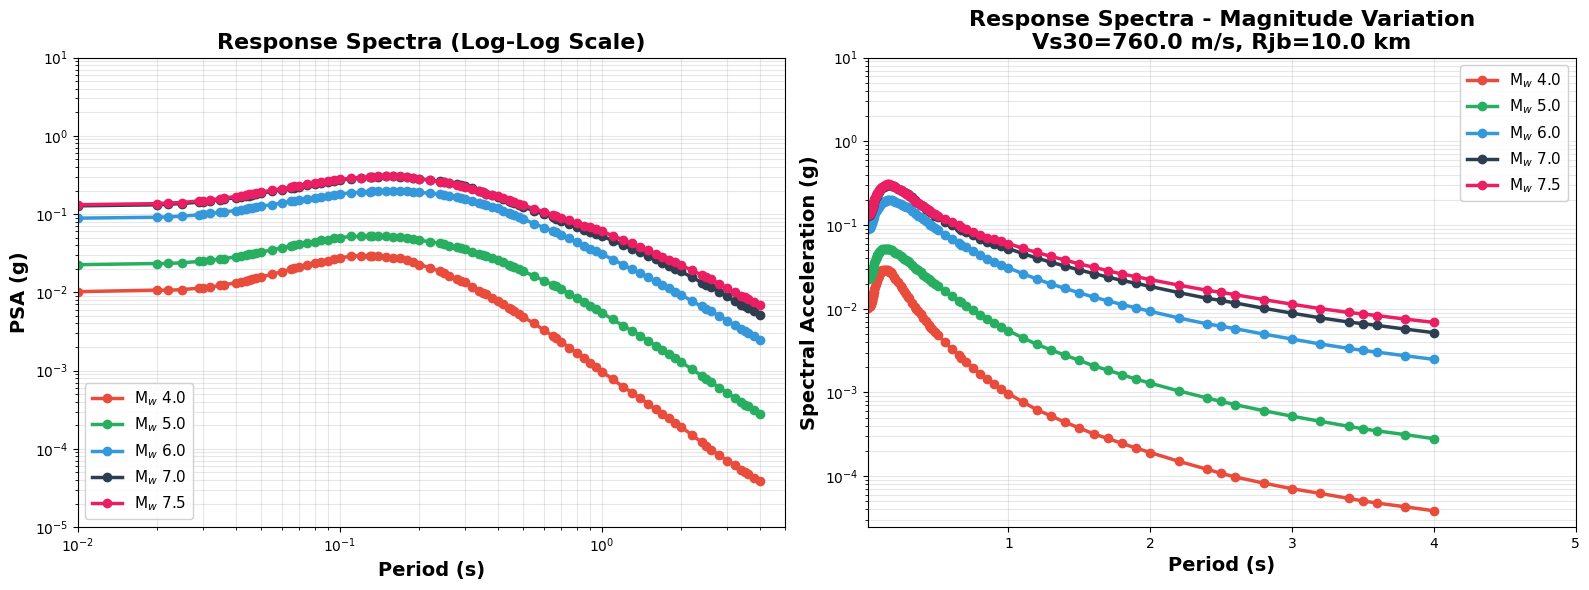


✓ Saved: assignments/3/parametric_study_magnitude.png

✓ PHASE 5.1 COMPLETE: Parametric study (Magnitude variation)


In [40]:
# Phase 5.1: Parametric Study - Response Spectra vs Magnitude
print("\n" + "="*80)
print("PHASE 5.1: PARAMETRIC STUDY - MAGNITUDE VARIATION")
print("="*80)

# Extract periods from column names using the existing period_to_float function from cell 3
# Need to manually extract periods by parsing column names
def extract_period(col_name):
    """Convert column name like T0pt010S to 0.010"""
    period_str = col_name[1:-1].replace('pt', '.')
    return float(period_str)

periods = [extract_period(col) for col in selected_period_cols_sorted]
print(f"\nUsing {len(periods)} spectral periods")
print(f"Period range: {min(periods):.3f}s - {max(periods):.3f}s")

# Fixed parameters (matching reference notebook)
fixed_rjb = 10.0  # km (close distance)
fixed_vs30 = 760.0  # m/s (Rock site, NEHRP Site Class B/C boundary)
fixed_fault_type = 0  # Strike-slip

print(f"\nFixed parameters:")
print(f"  Rjb = {fixed_rjb} km")
print(f"  Vs30 = {fixed_vs30} m/s (Rock site)")
print(f"  Fault Type = {fixed_fault_type} (Strike-slip)")

# Magnitude variations
magnitudes = [4.0, 5.0, 6.0, 7.0, 7.5]
colors = ['#E74C3C', '#27AE60', '#3498DB', '#2C3E50', '#E91E63']

print(f"\nMagnitude variations: {magnitudes}")

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for mag, color in zip(magnitudes, colors):
    # Prepare input features: [Earthquake_Magnitude, Rjb_km, log10_Rjb_km, log10_Vs30, Fault_Type]
    log_rjb = np.log10(fixed_rjb)
    log_vs30 = np.log10(fixed_vs30)
    X_pred = np.array([[mag, fixed_rjb, log_rjb, log_vs30, fixed_fault_type]])
    
    # Scale input
    X_pred_scaled = scaler_X.transform(X_pred)
    X_pred_tensor = torch.FloatTensor(X_pred_scaled).to(device)
    
    # Predict using trained model
    with torch.no_grad():
        y_pred_scaled = eval_model(X_pred_tensor).cpu().numpy()
    
    # Inverse transform predictions (from log space to linear)
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
    
    # Convert from log10 to linear space
    y_pred = 10 ** y_pred_log
    
    # Extract Sa values (indices 2 onwards, after PGA and PGV)
    # Output structure: [log10_PGA_g, log10_PGV_cm_sec, log10_Sa(T1), log10_Sa(T2), ...]
    sa_values = y_pred[0, 2:]  # Skip PGA (idx 0) and PGV (idx 1)
    
    # Plot on both axes (log-log and semi-log)
    ax1.loglog(periods, sa_values, marker='o', linestyle='-', linewidth=2.5, 
              label=f'M$_w$ {mag}', color=color, markersize=6)
    ax2.semilogy(periods, sa_values, marker='o', linestyle='-', linewidth=2.5, 
                label=f'M$_w$ {mag}', color=color, markersize=6)

# Configure first plot (log-log)
ax1.set_xlabel('Period (s)', fontsize=14, fontweight='bold')
ax1.set_ylabel('PSA (g)', fontsize=14, fontweight='bold')
ax1.set_title('Response Spectra (Log-Log Scale)', fontsize=16, fontweight='bold')
ax1.legend(fontsize=11, loc='lower left', framealpha=0.9)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim(0.01, 5)
ax1.set_ylim(0.00001, 10)

# Configure second plot (semi-log)
ax2.set_xlabel('Period (s)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Spectral Acceleration (g)', fontsize=14, fontweight='bold')
ax2.set_title(f'Response Spectra - Magnitude Variation\nVs30={fixed_vs30} m/s, Rjb={fixed_rjb} km', 
             fontsize=16, fontweight='bold')
ax2.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(0.01, 5)
ax2.set_ylim(-1, 10)

plt.tight_layout()
plot_path = os.path.join(plots_dir, 'parametric_study_magnitude.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n✓ Saved: {plot_path}")

print(f"\n{'='*80}")
print("✓ PHASE 5.1 COMPLETE: Parametric study (Magnitude variation)")
print(f"{'='*80}")


PHASE 5.2: PARAMETRIC STUDY - SITE CONDITION (Vs30) VARIATION

Fixed parameters:
  Magnitude = 6.5
  Rjb = 10.0 km
  Fault Type = 0 (Strike-slip)

Vs30 variations (NEHRP site classes): [150, 225, 370, 525, 1170]


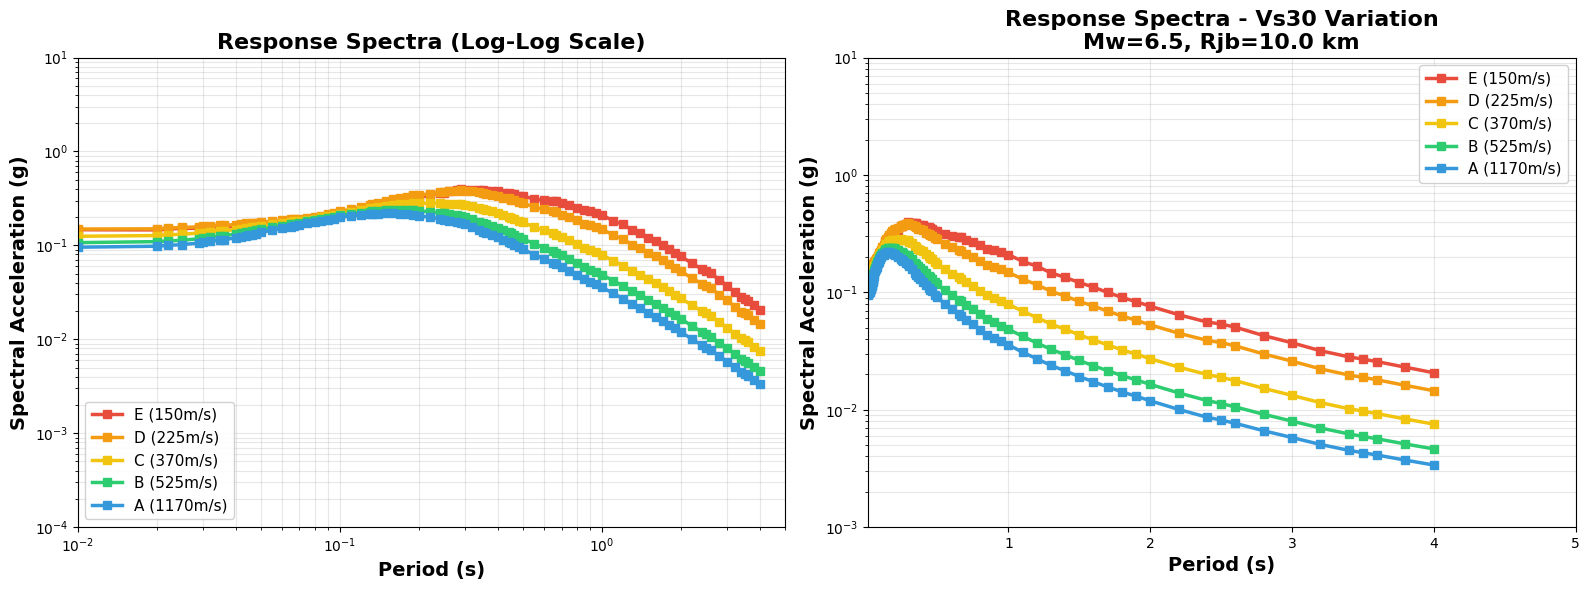


✓ Saved: assignments/3/parametric_study_vs30.png

✓ PHASE 5.2 COMPLETE: Parametric study (Vs30 variation)


In [36]:
# Phase 5.2: Parametric Study - Response Spectra vs Vs30
print("\n" + "="*80)
print("PHASE 5.2: PARAMETRIC STUDY - SITE CONDITION (Vs30) VARIATION")
print("="*80)

# Fixed parameters
fixed_mag = 6.5  # Moderate-large earthquake
fixed_rjb = 10.0  # km (close distance)
fixed_fault_type = 0  # Strike-slip

print(f"\nFixed parameters:")
print(f"  Magnitude = {fixed_mag}")
print(f"  Rjb = {fixed_rjb} km")
print(f"  Fault Type = {fixed_fault_type} (Strike-slip)")

# Vs30 variations (NEHRP site classes)
vs30_values = [150, 225, 370, 525, 1170]  # m/s
vs30_labels = ['E (150m/s)', 'D (225m/s)', 'C (370m/s)', 'B (525m/s)', 'A (1170m/s)']
colors = ['#E74C3C', '#F39C12', '#F1C40F', '#2ECC71', '#3498DB']

print(f"\nVs30 variations (NEHRP site classes): {vs30_values}")

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for vs30, label, color in zip(vs30_values, vs30_labels, colors):
    # Prepare input features: [Earthquake_Magnitude, Rjb_km, log10_Rjb_km, log10_Vs30, Fault_Type]
    log_rjb = np.log10(fixed_rjb)
    log_vs30 = np.log10(vs30)
    X_pred = np.array([[fixed_mag, fixed_rjb, log_rjb, log_vs30, fixed_fault_type]])
    
    # Scale input
    X_pred_scaled = scaler_X.transform(X_pred)
    X_pred_tensor = torch.FloatTensor(X_pred_scaled).to(device)
    
    # Predict using trained model
    with torch.no_grad():
        y_pred_scaled = eval_model(X_pred_tensor).cpu().numpy()
    
    # Inverse transform predictions (from log space to linear)
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
    
    # Convert from log10 to linear space
    y_pred = 10 ** y_pred_log
    
    # Extract Sa values (indices 2 onwards, after PGA and PGV)
    sa_values = y_pred[0, 2:]  # Skip PGA and PGV
    
    # Plot on both axes
    ax1.loglog(periods, sa_values, marker='s', linestyle='-', linewidth=2.5, 
              label=label, color=color, markersize=6)
    ax2.semilogy(periods, sa_values, marker='s', linestyle='-', linewidth=2.5, 
                label=label, color=color, markersize=6)

# Configure first plot (log-log)
ax1.set_xlabel('Period (s)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Spectral Acceleration (g)', fontsize=14, fontweight='bold')
ax1.set_title('Response Spectra (Log-Log Scale)', fontsize=16, fontweight='bold')
ax1.legend(fontsize=11, loc='lower left', framealpha=0.9)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim(0.01, 5)
ax1.set_ylim(0.0001, 10)

# Configure second plot (semi-log)
ax2.set_xlabel('Period (s)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Spectral Acceleration (g)', fontsize=14, fontweight='bold')
ax2.set_title(f'Response Spectra - Vs30 Variation\nMw={fixed_mag}, Rjb={fixed_rjb} km', 
             fontsize=16, fontweight='bold')
ax2.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(0.01, 5)
ax2.set_ylim(0.001, 10)

plt.tight_layout()
plot_path = os.path.join(plots_dir, 'parametric_study_vs30.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n✓ Saved: {plot_path}")

print(f"\n{'='*80}")
print("✓ PHASE 5.2 COMPLETE: Parametric study (Vs30 variation)")
print(f"{'='*80}")


PHASE 6.1: FEATURE IMPORTANCE ANALYSIS

Calculating permutation importance... This may take a moment.
Using 1000 samples for permutation importance calculation
Running permutation importance (10 repeats)...


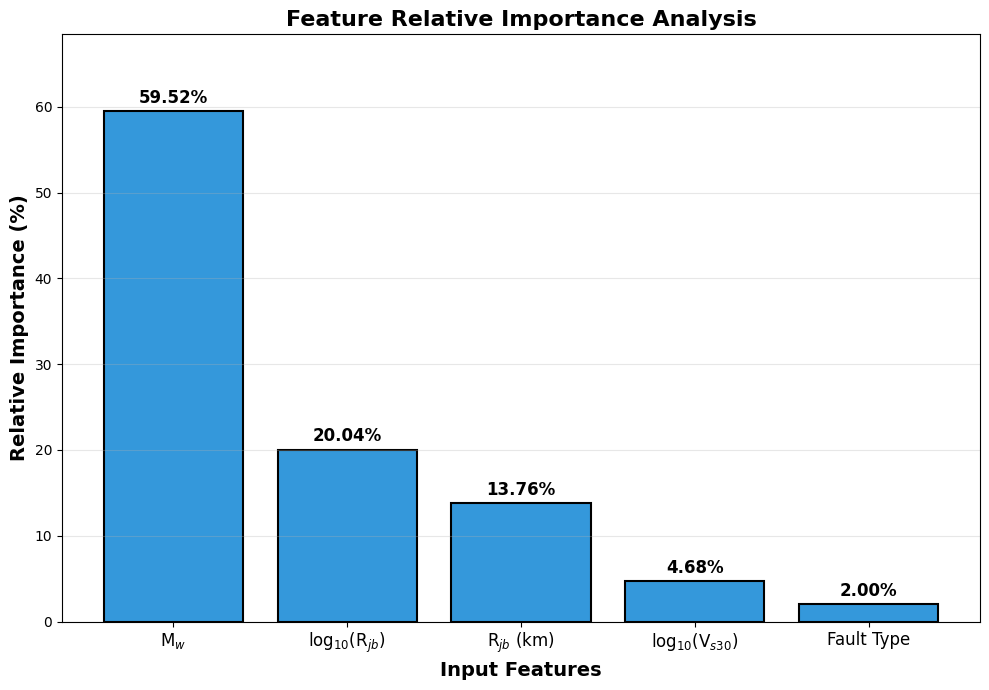


✓ Saved: assignments/3/feature_importance.png

Feature Importance Rankings:
1. Earthquake_Magnitude           :  59.52%
2. log10_Rjb_km                   :  20.04%
3. Rjb_km                         :  13.76%
4. log10_Vs30                     :   4.68%
5. Fault_Type                     :   2.00%

✓ PHASE 6.1 COMPLETE: Feature importance analysis


In [39]:
# Phase 6.1: Feature Importance Analysis using Permutation Importance
print("\n" + "="*80)
print("PHASE 6.1: FEATURE IMPORTANCE ANALYSIS")
print("="*80)

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error

# Calculate permutation importance
print("\nCalculating permutation importance... This may take a moment.")

# Use a subset for faster computation
n_samples = min(1000, X_test_scaled.shape[0])
indices = np.random.choice(X_test_scaled.shape[0], n_samples, replace=False)
X_sample = X_test_scaled[indices]
y_sample = y_test_scaled[indices]

print(f"Using {n_samples} samples for permutation importance calculation")

# Create a wrapper class to make PyTorch model compatible with sklearn
class PyTorchWrapper:
    """Wrapper to make PyTorch model compatible with sklearn permutation_importance"""
    def __init__(self, model, device):
        self.model = model
        self.device = device
    
    def fit(self, X, y):
        # Not needed for permutation importance, but required by sklearn interface
        return self
    
    def predict(self, X):
        """Predict using PyTorch model"""
        X_tensor = torch.FloatTensor(X).to(self.device)
        with torch.no_grad():
            y_pred = self.model(X_tensor).cpu().numpy()
        return y_pred
    
    def score(self, X, y):
        """Return negative MSE (for maximization)"""
        y_pred = self.predict(X)
        mse = mean_squared_error(y, y_pred)
        return -mse  # Negative because sklearn maximizes

# Wrap the model
wrapped_model = PyTorchWrapper(eval_model, device)

# Calculate importance
print("Running permutation importance (10 repeats)...")
perm_importance = permutation_importance(
    wrapped_model, X_sample, y_sample,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Extract mean importance and convert to percentage
importance_mean = -perm_importance.importances_mean  # Convert back to positive (lower MSE = higher importance)
importance_mean = (importance_mean / importance_mean.sum()) * 100

# Create feature names for display
feature_display_names = ['M$_w$', 'R$_{jb}$ (km)', 'log$_{10}$(R$_{jb}$)', 'log$_{10}$(V$_{s30}$)', 'Fault Type']

# Sort by importance
sorted_indices = np.argsort(importance_mean)[::-1]

# Plot relative importance
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

bars = ax.bar(range(len(importance_mean)), importance_mean[sorted_indices], 
              color='#3498DB', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, importance_mean[sorted_indices])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
           f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Input Features', fontsize=14, fontweight='bold')
ax.set_ylabel('Relative Importance (%)', fontsize=14, fontweight='bold')
ax.set_title('Feature Relative Importance Analysis', fontsize=16, fontweight='bold')
ax.set_xticks(range(len(importance_mean)))
ax.set_xticklabels([feature_display_names[i] for i in sorted_indices], fontsize=12)
ax.set_ylim(0, max(importance_mean) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plot_path = os.path.join(plots_dir, 'feature_importance.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n✓ Saved: {plot_path}")

print(f"\n{'='*60}")
print("Feature Importance Rankings:")
print(f"{'='*60}")
for i, idx in enumerate(sorted_indices, 1):
    print(f"{i}. {input_feature_cols[idx]:<30} : {importance_mean[idx]:>6.2f}%")
print(f"{'='*60}")

print(f"\n{'='*80}")
print("✓ PHASE 6.1 COMPLETE: Feature importance analysis")
print(f"{'='*80}")


PHASE 6.2: SHAP ANALYSIS

Calculating SHAP values for 200 samples...
This may take several minutes...
SHAP values type: <class 'numpy.ndarray'>
SHAP format: 3D array (200, 5, 92) (multi-output)
✓ Successfully processed SHAP values for 92 outputs
Visualizing SHAP values for outputs: ['PGA', 'PGV', 'Sa(0.010s)', 'Sa(0.032s)']


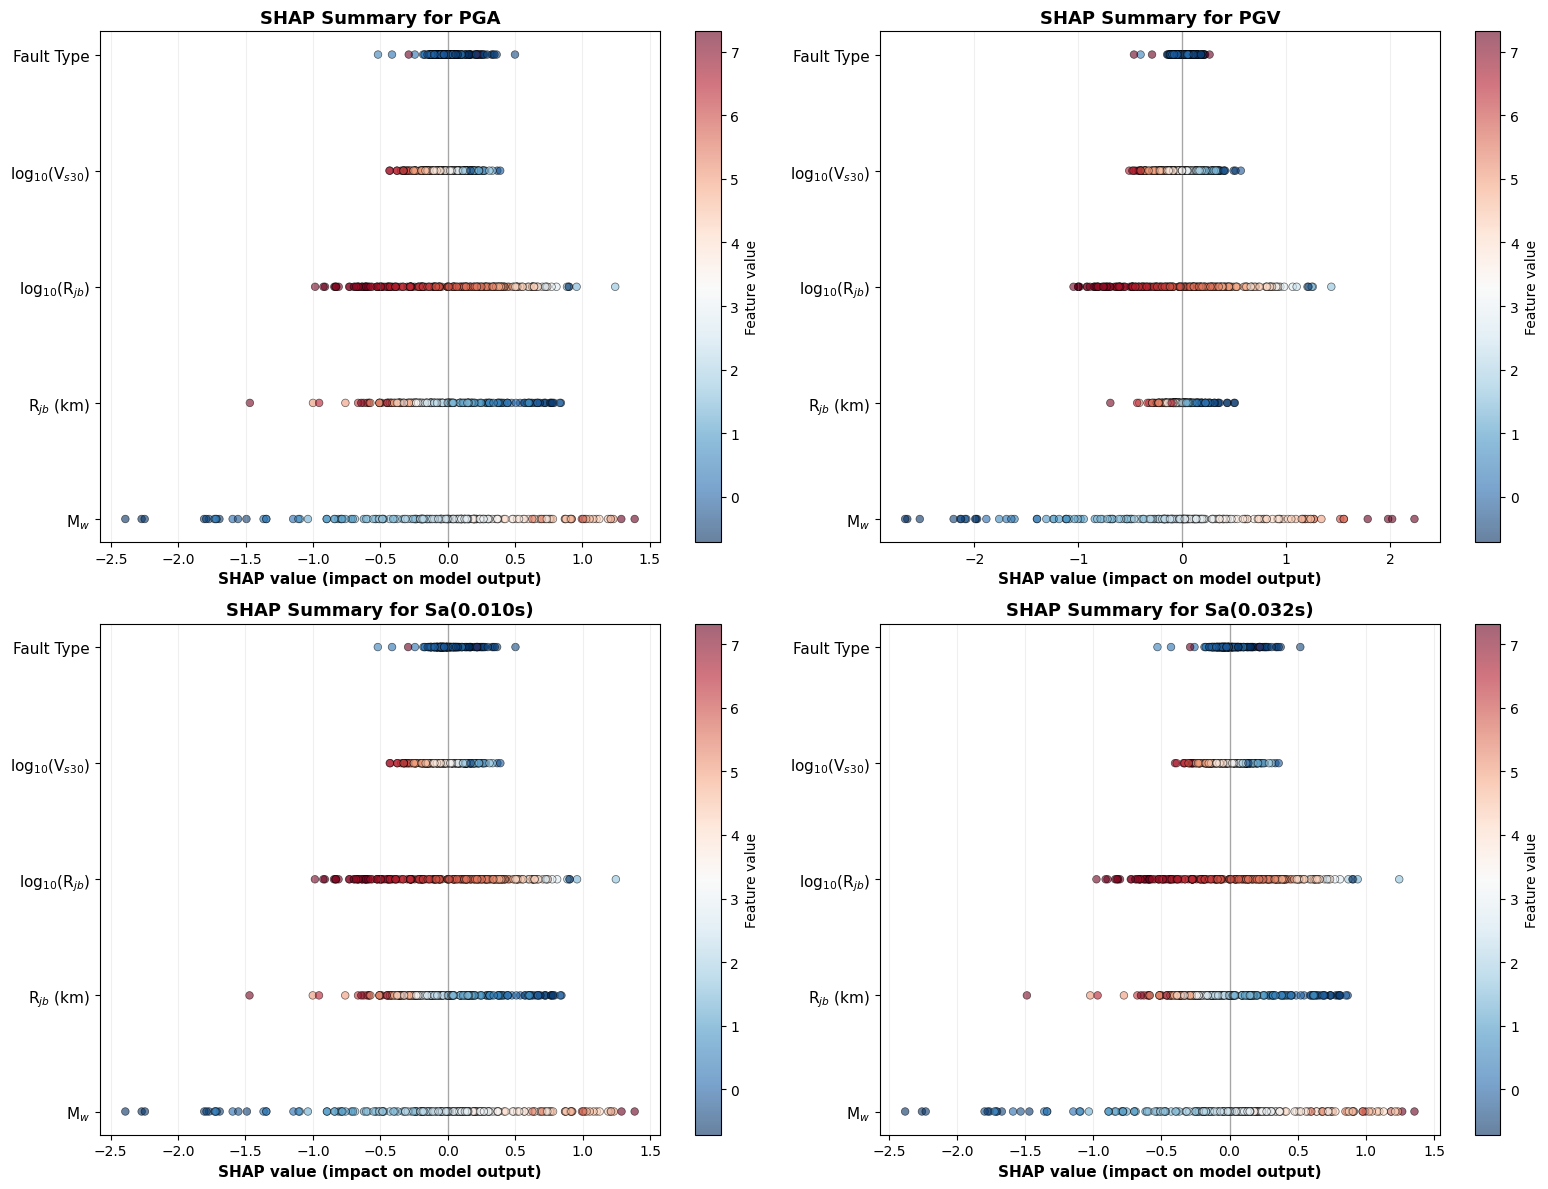


✓ Saved: assignments/3/shap_analysis.png

✓ PHASE 6.2 COMPLETE: SHAP analysis


In [42]:
# Phase 6.2: SHAP Analysis for Model Interpretability
print("\n" + "="*80)
print("PHASE 6.2: SHAP ANALYSIS")
print("="*80)

try:
    import shap
    
    # Use a sample of data for SHAP (computational efficiency)
    n_shap_samples = 200
    indices = np.random.choice(X_test_scaled.shape[0], min(n_shap_samples, X_test_scaled.shape[0]), replace=False)
    X_shap = X_test_scaled[indices]
    
    print(f"\nCalculating SHAP values for {X_shap.shape[0]} samples...")
    print("This may take several minutes...")
    
    # Create SHAP explainer for PyTorch model
    # Use GradientExplainer for neural networks (more efficient than DeepExplainer)
    background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]
    background_tensor = torch.FloatTensor(background).to(device)
    
    explainer = shap.GradientExplainer(eval_model, background_tensor)
    
    # Calculate SHAP values
    X_shap_tensor = torch.FloatTensor(X_shap).to(device)
    shap_values = explainer.shap_values(X_shap_tensor)
    
    # Robust handling of different SHAP value formats
    print(f"SHAP values type: {type(shap_values)}")
    
    # Convert SHAP values to a consistent format
    shap_values_list = None
    
    if isinstance(shap_values, list):
        # Already in list format (one array per output)
        shap_values_list = shap_values
        print(f"SHAP format: List of {len(shap_values)} arrays (multi-output)")
        
    elif isinstance(shap_values, np.ndarray):
        # Could be single output or multi-output as 3D array
        if shap_values.ndim == 2:
            # Single output: (n_samples, n_features)
            print(f"SHAP format: 2D array {shap_values.shape} (single output)")
            # Wrap in list for consistency
            shap_values_list = [shap_values]
            
        elif shap_values.ndim == 3:
            # Multi-output stored as: (n_samples, n_features, n_outputs)
            print(f"SHAP format: 3D array {shap_values.shape} (multi-output)")
            # Transpose to get list of (n_samples, n_features) arrays
            n_outputs = shap_values.shape[2]
            shap_values_list = [shap_values[:, :, i] for i in range(n_outputs)]
            
        else:
            print(f"⚠ Unexpected SHAP array dimensions: {shap_values.ndim}D with shape {shap_values.shape}")
            
    else:
        print(f"⚠ Unexpected SHAP values type: {type(shap_values)}")
    
    # Proceed with visualization if we have valid SHAP values
    if shap_values_list is not None and len(shap_values_list) > 0:
        print(f"✓ Successfully processed SHAP values for {len(shap_values_list)} outputs")
        
        # Analyze specific outputs of interest
        # Ensure output_indices are within valid range
        max_outputs = len(shap_values_list)
        output_indices = [i for i in [0, 1, 2, 8] if i < max_outputs]
        
        # Extract period value for Sa outputs
        def extract_period_value(idx):
            if idx < 2:
                return ['PGA', 'PGV'][idx]
            else:
                col_idx = idx - 2
                if col_idx < len(selected_period_cols_sorted):
                    col_name = selected_period_cols_sorted[col_idx]
                    period_str = col_name[1:-1].replace('pt', '.')
                    return f'Sa({period_str}s)'
                return f'Sa(idx{col_idx})'
        
        output_names_shap = [extract_period_value(i) for i in output_indices]
        
        print(f"Visualizing SHAP values for outputs: {output_names_shap}")
        
        # Create subplots
        n_plots = len(output_indices)
        n_rows = (n_plots + 1) // 2
        n_cols = min(2, n_plots)
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 6*n_rows))
        if n_plots == 1:
            axes = np.array([axes])
        else:
            axes = axes.flatten()
        
        # Feature names
        feature_names = ['M$_w$', 'R$_{jb}$ (km)', 'log$_{10}$(R$_{jb}$)', 'log$_{10}$(V$_{s30}$)', 'Fault Type']
        
        for idx, (out_idx, out_name) in enumerate(zip(output_indices, output_names_shap)):
            ax = axes[idx]
            
            # Get SHAP values for this output
            shap_output = shap_values_list[out_idx]
            
            # Convert to numpy if it's a tensor
            if torch.is_tensor(shap_output):
                shap_output = shap_output.cpu().numpy()
            
            # Verify shape
            if shap_output.shape[0] != X_shap.shape[0] or shap_output.shape[1] != X_shap.shape[1]:
                print(f"⚠ Shape mismatch for output {out_idx}: SHAP {shap_output.shape}, X_shap {X_shap.shape}")
                continue
            
            # Create beeswarm-like plot
            for feat_idx in range(min(len(feature_names), shap_output.shape[1])):
                shap_vals = shap_output[:, feat_idx]
                feature_vals = X_shap[:, feat_idx]
                
                # Create scatter with color based on feature value
                scatter = ax.scatter(shap_vals, [feat_idx] * len(shap_vals), 
                                   c=feature_vals, cmap='RdBu_r', 
                                   alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
            
            # Formatting
            ax.set_yticks(range(min(len(feature_names), shap_output.shape[1])))
            ax.set_yticklabels(feature_names[:shap_output.shape[1]], fontsize=11)
            ax.set_xlabel('SHAP value (impact on model output)', fontsize=11, fontweight='bold')
            ax.set_title(f'SHAP Summary for {out_name}', fontsize=13, fontweight='bold')
            ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
            ax.grid(True, alpha=0.2, axis='x')
            
            # Add colorbar
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('Feature value', fontsize=10)
        
        # Hide any unused subplots
        for idx in range(len(output_indices), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plot_path = os.path.join(plots_dir, 'shap_analysis.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f"\n✓ Saved: {plot_path}")
        
        print(f"\n{'='*80}")
        print("✓ PHASE 6.2 COMPLETE: SHAP analysis")
        print(f"{'='*80}")
        
    else:
        print("⚠ Could not process SHAP values - skipping visualization")
        
except ImportError:
    print("\n⚠ SHAP library not installed.")
    print("You can install it manually using: pip install shap")
    print("Skipping SHAP analysis for now.")
    
except Exception as e:
    print(f"\n⚠ Error during SHAP analysis: {str(e)}")
    import traceback
    traceback.print_exc()
    print("\nContinuing with other analyses...")